# Day-ahead load forecasting — portfolio of 410 heat-pump households

**Task.** At the **day-ahead gate closure (12:00 local time on D-1)** forecast the **aggregated load of all households
for every 15-min interval of day D** (96 values). **Only information available at that moment is used — no perfect
foresight of any kind.**

**Models**
| # | Model | Idea |
|---|---|---|
| 0a | Baseline | load of the same quarter-hour **7 days earlier** |
| 0b | Persistence | load of the same quarter-hour on the **most recent day known** at gate closure |
| 1 | Linear regression | ridge-regularised linear model on calendar, load-lag and past-weather features |
| 2 | Random forest | non-linear tree ensemble on the same features |
| 3 | Gradient boosting | histogram gradient boosting on the same features |
| 4 | LSTM | sequence-to-sequence network: encoder reads the last 7 × 24 h known at gate closure, decoder emits the 96 quarter-hours of day D |

**Notebook structure**
1. Setup & configuration
2. Data preparation (portfolio aggregation, weather, features, 80/20 split)
3. Feature importance analysis
4. Hyperparameter optimisation & training (time-series cross-validation inside the training period only)
5. Validation on the 20% hold-out test period
6. Conclusions

**Design decisions** (all configurable in section 1)
* **Target = aggregated load of all households.** The number of households in the data grows from ~10 (2019) to
  ~400 (2023). The models therefore learn the **load per household** (kWh / 15 min) and the forecast is multiplied by the
  number of households in the portfolio **on D-1** (the latest known portfolio size). Readings missing because of
  meter gaps are imputed with the mean of the other households. The baseline is applied literally to the aggregated
  load: `forecast(D, t) = total(D-7, t)`.
* **Modelling period** starts when ≥ `MIN_HOUSEHOLDS` (50) households report — the mean over a handful of houses
  is not representative (≈ Nov 2020 → Feb 2024).
* **Time axis:** fixed UTC+1 (CET without daylight saving), so every day has exactly 96 quarter-hours. A
  daylight-saving flag lets the models learn the 1-hour shift of human behaviour in summer. (The market day itself is
  defined in local time, so in summer day D on this axis is shifted by one hour against the delivery day.)
* **No perfect foresight.** The forecast for day D is issued at the day-ahead gate closure, 12:00 local time on D-1 —
  that is 11:00 on the UTC+1 axis in summer and 12:00 in winter, so the notebook uses **11:00 UTC+1** all year
  (`GATE_SLOT`). A forecast may only use
  * **meter readings up to quarter-hour `METER_SLOT_D1` of D-1** — default `0`: smart meters are read out once a day,
    so the load is known until 24:00 of **D-2** (`GATE_SLOT` = real-time meter data until gate closure),
  * **weather measured until gate closure on D-1** — the dataset contains no weather forecasts, so the weather of
    day D is **not** used in any form,
  * the calendar of day D (weekday, public holiday, daylight saving) — known in advance,
  * the portfolio size of D-1.

  All load and weather features are rolling windows that end at the last quarter-hour known at gate closure.
  `METER_SLOT_D1 = WX_SLOT_D1 = STEPS` reproduces the former setting "everything until 24:00 of D-1" — that is
  **after** gate closure, cannot be used for day-ahead bidding and gives too optimistic errors.

  The pre-processing is causal as well: hourly weather is upsampled by *holding* each hourly value (no interpolation
  towards later measurements), gaps in the load history are filled only with earlier values, and all scalers,
  feature analyses and hyperparameter searches use the training period only.
* **Split:** first 80% of days = training, last 20% = test. Hyperparameters are tuned with expanding-window
  cross-validation **inside** the training period (`N_FOLDS` validation folds of one quarter each, every fold trains on
  more than 1.5 years); the test period is used exactly once, for the final validation.

## 1. Setup & configuration

In [77]:
import copy
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.easter import easter
from IPython.display import display

import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 40)

# ---------------- configuration ----------------
DATA = Path("data")
CACHE = DATA / "_cache"
RESULTS = Path("results")
CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

TZ = "Etc/GMT-1"         # fixed UTC+1 (no DST) -> every day has exactly 96 quarter-hours
STEPS = 96               # quarter-hours per day
MIN_HOUSEHOLDS = 50      # modelling period starts once at least this many households report
MAX_KWH_15MIN = 10.0     # single readings above 10 kWh / 15 min (= 40 kW) are meter errors -> dropped
TEST_SHARE = 0.2         # last 20% of the days = test set

# ---------------- information available at forecast time ----------------
# Day-ahead gate closure (EPEX) is 12:00 local time on D-1 = 11:00 on the fixed UTC+1 axis in summer, 12:00 in winter.
GATE_SLOT = 44           # forecast is issued before quarter-hour 44 (11:00 UTC+1) of D-1 -> conservative all year
WX_SLOT_D1 = GATE_SLOT   # weather measurements of D-1 are known for quarter-hours < WX_SLOT_D1
METER_SLOT_D1 = 0        # meter readings of D-1 are known for quarter-hours < METER_SLOT_D1:
                         #   0         = daily meter read-out, data complete until 24:00 of D-2 (realistic default)
                         #   GATE_SLOT = real-time meter data until gate closure
                         #   STEPS     = everything until 24:00 of D-1 (old setting, AFTER gate closure; set WX_SLOT_D1 = STEPS too)
assert 0 <= METER_SLOT_D1 <= WX_SLOT_D1 <= STEPS and METER_SLOT_D1 % 4 == 0

# ---------------- cross-validation & hyperparameter optimisation ----------------
N_FOLDS = 4              # expanding-window CV folds inside the training period ...
CV_VAL_DAYS = 91         # ... each validating one quarter -> the folds cover all seasons, every fold trains on > 1.5 years
RUN_HPO = True           # False -> reuse the best parameters stored in data/_cache/best_params.json
N_TRIALS_RF = 30         # TPE samples the first 10 trials at random -> with fewer trials it is just a random search
N_TRIALS_GB = 40
N_TRIALS_LSTM = 30
RF_TREES_HPO = 150       # more trees never hurt a random forest -> not tuned; fewer trees during the search for speed
RF_TREES_FINAL = 400
LSTM_MAX_EPOCHS = 150
LSTM_PATIENCE = 15
LSTM_ENSEMBLE = 3        # final LSTM = average of this many seeds (reduces run-to-run variance)
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))

# ---------------- plotting ----------------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
C_BLUE, C_ORANGE, C_AQUA = PALETTE[:3]
C_GREY, C_INK = "#9a9994", "#0b0b0b"
MODEL_COLORS = {"Baseline (t-7d)": C_GREY, "Persistence": PALETTE[6], "Linear regression": C_BLUE,
                "Random forest": C_ORANGE, "Gradient boosting": PALETTE[3], "LSTM": C_AQUA}
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (12, 4.5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "lines.linewidth": 2, "legend.frameon": False,
})
print(f"torch {torch.__version__} | optuna {optuna.__version__} | threads {torch.get_num_threads()}")

torch 2.14.1+cpu | optuna 5.0.0 | threads 8


## 2. Data preparation
### 2.1 Aggregate all households to one 15-min portfolio series
For every quarter-hour we store the **sum** over all reporting households and the **number** of reporting households.
Implausible single readings (> 10 kWh per 15 min, found in the EDA) are discarded. Result is cached.

In [78]:
AGG_FILE = CACHE / "portfolio_15min.pkl"     # delete the file after changing MAX_KWH_15MIN, the cache does not notice it
if AGG_FILE.exists():
    agg15 = pd.read_pickle(AGG_FILE)
    print("Loaded", AGG_FILE)
else:
    t0 = time.time()
    grid = pd.date_range("2019-05-20", "2024-02-28", freq="15min", tz="UTC", inclusive="left")
    s_sum = np.zeros(len(grid))
    s_cnt = np.zeros(len(grid), dtype=np.int32)
    n_dropped = n_outside = 0
    for f in sorted((DATA / "15min").glob("*.csv")):
        d = pd.read_csv(f, sep=";", usecols=["Timestamp", "kWh_received_Total"]).drop_duplicates("Timestamp")
        ts = pd.to_datetime(d.Timestamp, utc=True, format="%Y-%m-%d %H:%M:%S%z")
        pos = ((ts - grid[0]) // pd.Timedelta("15min")).to_numpy()
        val = d.kWh_received_Total.to_numpy(dtype=float)
        inside = (pos >= 0) & (pos < len(grid))      # np.add.at would silently wrap negative positions to the end
        ok = inside & ~np.isnan(val) & (val >= 0) & (val <= MAX_KWH_15MIN)
        n_dropped += int((inside & ((val < 0) | (val > MAX_KWH_15MIN))).sum())
        n_outside += int((~inside).sum())
        np.add.at(s_sum, pos[ok], val[ok])
        np.add.at(s_cnt, pos[ok], 1)
    agg15 = pd.DataFrame({"sum": s_sum, "n": s_cnt}, index=grid)
    agg15.to_pickle(AGG_FILE)
    print(f"Aggregated 410 files in {time.time() - t0:.0f}s, dropped {n_dropped} implausible readings and "
          f"{n_outside} readings outside the time grid -> {AGG_FILE}")

agg15 = agg15.tz_convert(TZ)
agg15.describe().T

Loaded data\_cache\portfolio_15min.pkl


,count,mean,std,min,25%,50%,75%,max
sum,"167,520.0000",50.1588,54.0592,0.0000,7.4280,33.8430,69.1270,318.7700
n,"167,520.0000",165.1329,141.7540,0.0000,31.0000,118.0000,323.0000,390.0000


### 2.2 Contracted households per day and the target
A household counts as *contracted* on every day between its first and last timestamp
(`smart_meter_data_15min_overview.csv`), split by its weather station (needed for weighting the weather in 2.3).

In [79]:
META = DATA / "smart_meter_meta_data"
households = pd.read_csv(META / "households.csv", sep=";")
overview = pd.read_csv(META / "smart_meter_data_15min_overview.csv", sep=";")
ov = overview.merge(households[["Household_ID", "Weather_ID"]], on="Household_ID")
ov["first_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_EarliestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")
ov["last_day"] = pd.to_datetime(ov.SMD_15min_TimeAvailable_LatestTimestamp, utc=True).dt.tz_convert(TZ).dt.floor("D")

all_days = pd.date_range(ov.first_day.min(), ov.last_day.max(), freq="D")
n_contract_st = pd.DataFrame(0, index=all_days, columns=sorted(ov.Weather_ID.unique()))
for r in ov.itertuples():
    n_contract_st.loc[r.first_day:r.last_day, r.Weather_ID] += 1
n_contract = n_contract_st.sum(axis=1)

# modelling period: from the first day on which >= MIN_HOUSEHOLDS report in every quarter-hour
daily_min_n = agg15.n.resample("D").min()
start_day = daily_min_n[daily_min_n >= MIN_HOUSEHOLDS].index[0]
last_day = (agg15.index[-1] + pd.Timedelta("15min")).floor("D") - pd.Timedelta(days=1)
df = agg15.loc[start_day: last_day + pd.Timedelta(hours=23, minutes=45)].copy()
df["mean_kwh"] = df["sum"] / df["n"].where(df["n"] >= MIN_HOUSEHOLDS)        # load per reporting household
df["mean_kwh_hist"] = df.mean_kwh.ffill(limit=8)   # causal copy for the features: last observed value, max. 2 h

# target only: interpolate short gaps (<= 2 h) between the neighbouring measurements, keep longer gaps missing
na = df.mean_kwh.isna()
run_len = na.groupby((na != na.shift()).cumsum()).transform("sum")
fill = na & (run_len <= 8)
df.loc[fill, "mean_kwh"] = df.mean_kwh.interpolate(limit_area="inside")[fill]
print(f"Interpolated {fill.sum()} quarter-hours in short gaps; {df.mean_kwh.isna().sum()} quarter-hours remain missing")
df["n_contract"] = n_contract.reindex(df.index.floor("D")).to_numpy()
df["total_kwh"] = df.mean_kwh * df.n_contract                                 # aggregated portfolio load
print(f"Modelling period: {start_day:%Y-%m-%d} -> {last_day:%Y-%m-%d}  ({len(df) // STEPS} days, {len(df):,d} quarter-hours)")

Interpolated 0 quarter-hours in short gaps; 288 quarter-hours remain missing
Modelling period: 2020-11-04 -> 2024-02-27  (1211 days, 116,256 quarter-hours)


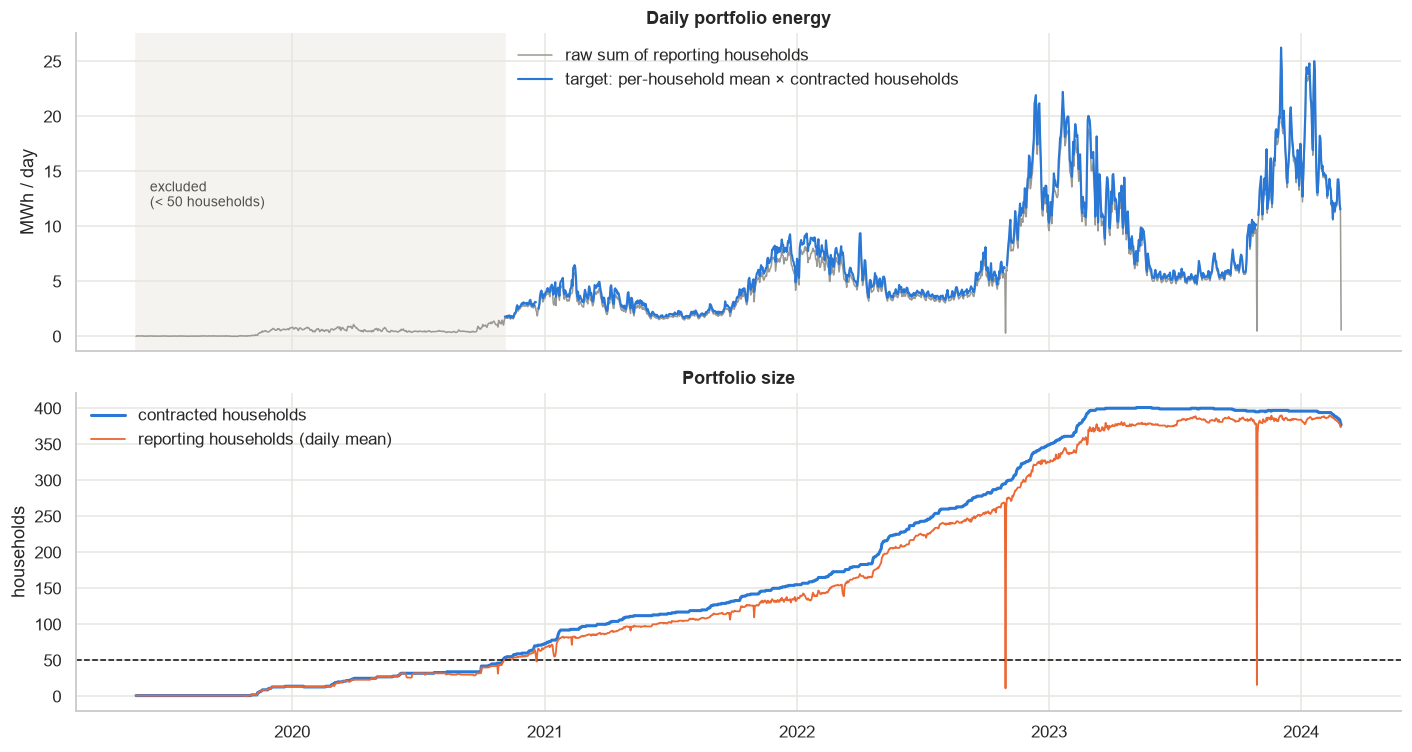

In [80]:
full = agg15.assign(day=agg15.index.floor("D"))
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
daily_tot = (full["sum"].resample("D").sum() / 1000)
axes[0].plot(daily_tot.index, daily_tot, color=C_GREY, lw=1, label="raw sum of reporting households")
dt = df.total_kwh.resample("D").sum(min_count=STEPS) / 1000
axes[0].plot(dt.index, dt, color=C_BLUE, lw=1.4, label="target: per-household mean × contracted households")
axes[0].axvspan(daily_tot.index[0], start_day, color="#f4f3ef", zorder=0)
axes[0].text(daily_tot.index[20], dt.max() * .45, f"excluded\n(< {MIN_HOUSEHOLDS} households)", fontsize=9, color="#52514e")
axes[0].set_ylabel("MWh / day"); axes[0].set_title("Daily portfolio energy"); axes[0].legend(loc="upper center")
axes[1].plot(n_contract.index, n_contract, color=C_BLUE, label="contracted households")
axes[1].plot(daily_min_n.index, agg15.n.resample("D").mean(), color=C_ORANGE, lw=1.2, label="reporting households (daily mean)")
axes[1].axhline(MIN_HOUSEHOLDS, color=C_INK, ls="--", lw=1)
axes[1].set_ylabel("households"); axes[1].set_title("Portfolio size"); axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

### 2.3 Weather: one portfolio-weighted series at 15-min resolution
Hourly station data are upsampled to 15 min by **holding each hourly value for its four quarter-hours** (no
interpolation, so no quarter-hour ever sees a later measurement) and averaged over the 8 stations,
**weighted by the number of contracted households at each station** on that day. Stations missing a variable are
left out of that variable's average.

These series enter the models only **up to the forecast time** (quarter-hours < `WX_SLOT_D1` of D-1, section 1).
Whether an hourly value is labelled with the start or the end of its hour is not documented; holding it from its time
stamp and cutting at 11:00 UTC+1 is safe for both conventions. The weather of the target day itself is used solely to
*describe* test days in section 5 (e.g. "coldest day"), never as model input.

In [81]:
weather = pd.concat([pd.read_csv(f, sep=";") for f in sorted((DATA / "weather_data_hourly").glob("*.csv"))],
                    ignore_index=True)
weather["Timestamp"] = pd.to_datetime(weather.Timestamp, utc=True).dt.tz_convert(TZ)
WX_MAP = {"Temperature_avg_hourly": "temp", "Sunshine_duration_hourly": "sunshine",
          "Humidity_avg_hourly": "humidity", "WindSpeed_hourly": "wind"}

def portfolio_weighted(wide):
    W = n_contract_st.reindex(wide.index.floor("D")).fillna(0).to_numpy(float)
    V = wide.reindex(columns=n_contract_st.columns).to_numpy(float)
    W = np.where(np.isnan(V), 0.0, W)
    with np.errstate(invalid="ignore", divide="ignore"):
        return pd.Series(np.nansum(V * W, axis=1) / W.sum(axis=1), index=wide.index)

for raw, name in WX_MAP.items():
    wide = weather.pivot_table(index="Timestamp", columns="Weather_ID", values=raw).asfreq("h")
    up = wide.resample("15min").asfreq()
    up = up.ffill(limit=3)                       # zero-order hold: causal
    df[name] = portfolio_weighted(up).reindex(df.index).to_numpy()

display(df[list(WX_MAP.values())].describe().T)
print("Missing weather values in modelling period:", df[list(WX_MAP.values())].isna().sum().to_dict())

,count,mean,std,min,25%,50%,75%,max
temp,"116,256.0000",10.0484,8.0483,-11.9720,3.5781,9.3490,15.8346,35.4020
sunshine,"116,256.0000",0.1971,0.3568,0.0000,0.0000,0.0000,0.1733,1.0000
humidity,"116,256.0000",77.5855,17.1885,19.1140,67.2078,82.5057,91.4812,99.6068
wind,"116,256.0000",2.0589,1.5007,0.1714,0.9610,1.6095,2.7429,11.4475


Missing weather values in modelling period: {'temp': 0, 'sunshine': 0, 'humidity': 0, 'wind': 0}


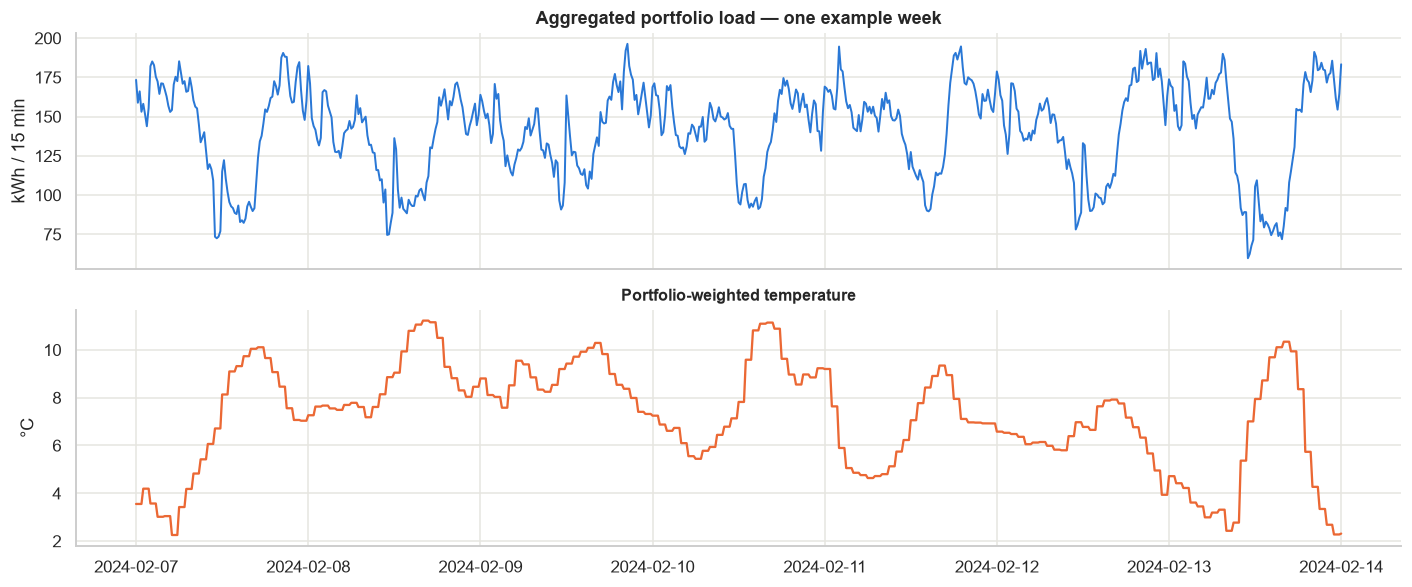

In [82]:
wk = df.loc[df.index[-STEPS * 21]: df.index[-STEPS * 14]]
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(wk.index, wk.total_kwh, color=C_BLUE, lw=1.3)
axes[0].set_ylabel("kWh / 15 min"); axes[0].set_title("Aggregated portfolio load — one example week")
axes[1].plot(wk.index, wk.temp, color=C_ORANGE, lw=1.5)
axes[1].set_ylabel("°C"); axes[1].set_title("Portfolio-weighted temperature", fontsize=10.5)
plt.tight_layout(); plt.show()

### 2.4 Day × quarter-hour matrices and data validity
Each day becomes one row of 96 quarter-hours. A day is **valid** as a forecast **target** if all 96 quarter-hours
have a load value (≥ `MIN_HOUSEHOLDS` reporting households, short gaps interpolated).

For the **history** (lag features, LSTM input, baselines) a separate, causal matrix is used: a missing quarter-hour is
replaced by the last observed value (≤ 2 h) or else by the same quarter-hour of the previous day. This matters
because the raw data contain no readings at all on the days the clocks go back (last Sunday of October); without
filling, that single day would also remove the following week (the history window reaches back 7–8 days).

In [83]:
day_index = pd.date_range(start_day, last_day, freq="D")
N_DAYS = len(day_index)
assert len(df) == N_DAYS * STEPS

def daymat(col):
    return pd.DataFrame(df[col].to_numpy(dtype=float).reshape(N_DAYS, STEPS), index=day_index)

Wx = {c: daymat(c) for c in WX_MAP.values()}
Ymat = daymat("mean_kwh")
day_ok = Ymat.notna().all(axis=1)
Ymat = Ymat.where(day_ok)                     # target matrix: invalid days -> NaN
Yhist = daymat("mean_kwh_hist").ffill(limit=1)   # causal history matrix: remaining gaps <- same quarter-hour of D-1
hist_ok = Yhist.notna().all(axis=1).astype(float)
# the history window (7 × 24 h ending at the forecast time) covers D-7 … D-1, or reaches into D-8 if D-1 is not complete
HIST_DAYS = 7 if METER_SLOT_D1 == STEPS else 8
usable = day_ok & (hist_ok.shift(1).rolling(HIST_DAYS).sum() == HIST_DAYS)   # target day valid + complete history
print(f"Days: {N_DAYS} | valid: {day_ok.sum()} | usable as target (incl. {HIST_DAYS}-day history): {usable.sum()}")
print("Invalid days:", [f"{d:%Y-%m-%d}" for d in day_index[~day_ok]])

Days: 1211 | valid: 1205 | usable as target (incl. 8-day history): 1197
Invalid days: ['2020-12-20', '2020-12-21', '2022-10-30', '2022-10-31', '2023-10-29', '2023-10-30']


### 2.5 Feature engineering
One row per **(target day D, quarter-hour t)**. **Every feature is known at the forecast time** (gate closure on D-1,
section 1):
* `lag_recent` / `temp_recent` / `sunshine_recent` take the same quarter-hour from the most recent day on which it has
  already been measured (D-1 before the cutoff, D-2 after it — `latest_known()`),
* all other load and weather statistics are **trailing windows that end at the last known quarter-hour**
  (`trailing()`), e.g. `load_mean_24h` = mean of the last 96 known quarter-hours,
* calendar features of day D are deterministic.

With `METER_SLOT_D1 = WX_SLOT_D1 = STEPS` the features are identical to plain D-1 lags (the former setting).

In [84]:
def ch_holidays(years):
    # Swiss national / widespread public holidays
    out = set()
    for y in years:
        e = pd.Timestamp(easter(y))
        out |= {pd.Timestamp(y, 1, 1), pd.Timestamp(y, 1, 2), e - pd.Timedelta(days=2), e + pd.Timedelta(days=1),
                e + pd.Timedelta(days=39), e + pd.Timedelta(days=50), pd.Timestamp(y, 8, 1),
                pd.Timestamp(y, 12, 25), pd.Timestamp(y, 12, 26)}
    return out

HOLIDAYS = ch_holidays(range(day_index[0].year, day_index[-1].year + 1))
naive_days = day_index.tz_localize(None)
flat = lambda m: np.asarray(m, dtype=float).ravel()          # (days, 96) -> day-major vector
per_day = lambda s: np.repeat(np.asarray(s, dtype=float), STEPS)
slot = np.tile(np.arange(STEPS), N_DAYS)
offday = pd.Series(((naive_days.dayofweek >= 5) | naive_days.isin(HOLIDAYS)).astype(float), index=day_index)

# ---- causal helpers: every value is taken at the forecast time (gate closure on D-1, see section 1)
H_FLAT = Yhist.to_numpy().ravel()                            # gap-filled load history, one value per quarter-hour
WX_FLAT = {c: m.to_numpy().ravel() for c, m in Wx.items()}

def latest_known(M, n_known_d1):
    """Same quarter-hour on the most recent day on which it is known at forecast time:
    D-1 for quarter-hours < n_known_d1, otherwise D-2 (n_known_d1 = STEPS -> plain D-1 lag)."""
    known = np.arange(STEPS) < n_known_d1
    return pd.DataFrame(np.where(known, M.shift(1).to_numpy(), M.shift(2).to_numpy()), index=M.index)

def trailing(x, window, n_known_d1, how="mean"):
    """Statistic over the last `window` quarter-hours known at forecast time, one value per target day D.
    The window ends with quarter-hour n_known_d1 - 1 of D-1 (n_known_d1 = 0 -> last quarter-hour of D-2)."""
    r = getattr(pd.Series(x).rolling(window, min_periods=window), how)().to_numpy()
    end = (np.arange(N_DAYS) - 1) * STEPS + n_known_d1 - 1   # flat position of the last known quarter-hour
    out = np.full(N_DAYS, np.nan)
    out[end >= 0] = r[end[end >= 0]]
    return pd.Series(out, index=day_index)

tab = pd.DataFrame(index=pd.MultiIndex.from_product([day_index, range(STEPS)], names=["day", "slot"]))
tab["y"] = flat(Ymat)
# ---- load history known at forecast time (meter data of D-1 only for quarter-hours < METER_SLOT_D1)
tab["lag_recent"] = flat(latest_known(Yhist, METER_SLOT_D1))
tab["lag_2d"] = flat(Yhist.shift(2))
tab["lag_7d"] = flat(Yhist.shift(7))
tab["load_mean_24h"] = per_day(trailing(H_FLAT, STEPS, METER_SLOT_D1))
tab["load_mean_7d"] = per_day(trailing(H_FLAT, 7 * STEPS, METER_SLOT_D1))
tab["load_max_24h"] = per_day(trailing(H_FLAT, STEPS, METER_SLOT_D1, "max"))
tab["load_last"] = per_day(trailing(H_FLAT, 1, METER_SLOT_D1))
# ---- weather measured until the forecast time (no information about the weather of day D)
t_mean = trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1)
tab["temp_recent"] = flat(latest_known(Wx["temp"], WX_SLOT_D1))
tab["sunshine_recent"] = flat(latest_known(Wx["sunshine"], WX_SLOT_D1))
tab["temp_mean_24h"] = per_day(t_mean)
tab["temp_min_24h"] = per_day(trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1, "min"))
tab["temp_max_24h"] = per_day(trailing(WX_FLAT["temp"], STEPS, WX_SLOT_D1, "max"))
tab["hdd_24h"] = per_day((20 - t_mean).where(t_mean < 12, 0).where(t_mean.notna()))
tab["sunshine_24h"] = per_day(trailing(WX_FLAT["sunshine"], STEPS, WX_SLOT_D1, "sum") / 4)
tab["humidity_24h"] = per_day(trailing(WX_FLAT["humidity"], STEPS, WX_SLOT_D1))
tab["wind_24h"] = per_day(trailing(WX_FLAT["wind"], STEPS, WX_SLOT_D1))
tab["temp_last"] = per_day(trailing(WX_FLAT["temp"], 1, WX_SLOT_D1))
tab["temp_trend"] = per_day(t_mean - t_mean.shift(1))                    # last 24 h minus the 24 h before
tab["temp_mean_7d"] = per_day(trailing(WX_FLAT["temp"], 7 * STEPS, WX_SLOT_D1))
# ---- calendar
dow = naive_days.dayofweek.to_numpy()
tab["slot"] = slot
tab["hour"] = slot // 4
tab["tod_sin"], tab["tod_cos"] = np.sin(2 * np.pi * slot / STEPS), np.cos(2 * np.pi * slot / STEPS)
tab["dow"] = per_day(dow)
tab["dow_sin"], tab["dow_cos"] = per_day(np.sin(2 * np.pi * dow / 7)), per_day(np.cos(2 * np.pi * dow / 7))
tab["is_weekend"] = per_day(dow >= 5)
tab["is_holiday"] = per_day(naive_days.isin(HOLIDAYS))
tab["is_xmas"] = per_day(((naive_days.month == 12) & (naive_days.day >= 24)) | ((naive_days.month == 1) & (naive_days.day <= 6)))
doy = naive_days.dayofyear.to_numpy()
tab["doy_sin"], tab["doy_cos"] = per_day(np.sin(2 * np.pi * doy / 365.25)), per_day(np.cos(2 * np.pi * doy / 365.25))
tab["is_dst"] = per_day([pd.Timestamp(f"{d:%Y-%m-%d} 12:00", tz="Europe/Zurich").dst() != pd.Timedelta(0) for d in naive_days])
tab["offday_d1"] = per_day(offday.shift(1))      # was a lagged day a weekend / holiday? (its profile then differs)
tab["offday_d2"] = per_day(offday.shift(2))
tab["offday_d7"] = per_day(offday.shift(7))
# ---- bookkeeping (not features)
tab["n_contract"] = per_day(n_contract.reindex(day_index))                 # true portfolio size of D (target only)
tab["n_contract_prev"] = per_day(n_contract.reindex(day_index).shift(1))  # portfolio size known at forecast time
tab["total"] = tab.y * tab.n_contract
tab["baseline_total"] = flat(Yhist.shift(7)) * per_day(n_contract.reindex(day_index).shift(7))
tab["persist_total"] = tab.lag_recent * tab.n_contract_prev               # persistence: latest known same quarter-hour

LAG_COLS = ["lag_recent", "lag_2d", "lag_7d", "load_mean_24h", "load_mean_7d", "load_max_24h", "load_last"]
if METER_SLOT_D1 == 0:
    LAG_COLS.remove("lag_2d")                    # identical to lag_recent when no meter data of D-1 are known
WX_PAST_COLS = ["temp_recent", "sunshine_recent", "temp_mean_24h", "temp_min_24h", "temp_max_24h",
                "hdd_24h", "sunshine_24h", "humidity_24h", "wind_24h", "temp_last", "temp_trend",
                "temp_mean_7d"]
CAL_COLS = ["slot", "tod_sin", "tod_cos", "dow", "dow_sin", "dow_cos", "is_weekend", "is_holiday", "is_xmas",
            "doy_sin", "doy_cos", "is_dst", "offday_d1", "offday_d2", "offday_d7"]
FEATURES = LAG_COLS + WX_PAST_COLS + CAL_COLS
print(f"{len(FEATURES)} features | table shape {tab.shape} | "
      f"meter data of D-1 known for {METER_SLOT_D1} quarter-hours, weather for {WX_SLOT_D1}")

33 features | table shape (116256, 41) | meter data of D-1 known for 0 quarter-hours, weather for 44


In [85]:
FEATURE_DOC = {
    "lag_recent": "load at the same quarter-hour on the most recent day on which it is known (D-1 / D-2)",
    "lag_2d": "load at the same quarter-hour on D-2", "lag_7d": "load at the same quarter-hour on D-7",
    "load_mean_24h": "mean load of the last 24 h known at forecast time",
    "load_mean_7d": "mean load of the last 7 × 24 h known at forecast time",
    "load_max_24h": "peak load of the last 24 h known at forecast time",
    "load_last": "last quarter-hour load known at forecast time",
    "temp_recent": "temperature at the same quarter-hour on the most recent day on which it is known",
    "sunshine_recent": "sunshine at the same quarter-hour on the most recent day on which it is known",
    "temp_mean_24h": "mean temperature of the last 24 h before the forecast",
    "temp_min_24h": "min temperature of the last 24 h", "temp_max_24h": "max temperature of the last 24 h",
    "hdd_24h": "heating degrees SIA 12/20 of the last 24 h", "sunshine_24h": "sunshine hours of the last 24 h",
    "humidity_24h": "mean rel. humidity of the last 24 h", "wind_24h": "mean wind speed of the last 24 h",
    "temp_last": "last temperature measured before the forecast",
    "temp_trend": "mean temperature of the last 24 h minus the 24 h before",
    "temp_mean_7d": "mean temperature of the last 7 × 24 h",
    "slot": "quarter-hour of day (0–95)",
    "tod_sin": "time of day (sin)", "tod_cos": "time of day (cos)", "dow": "day of week (0=Mon)",
    "dow_sin": "day of week (sin)", "dow_cos": "day of week (cos)", "is_weekend": "Saturday / Sunday",
    "is_holiday": "Swiss public holiday", "is_xmas": "Christmas / New-Year period (24.12.–6.1.)",
    "doy_sin": "day of year (sin)", "doy_cos": "day of year (cos)", "is_dst": "summer time in Switzerland",
    "offday_d1": "D-1 was a weekend day / holiday", "offday_d2": "D-2 was a weekend day / holiday",
    "offday_d7": "D-7 was a weekend day / holiday",
}
group = lambda f: "load lag" if f in LAG_COLS else "past weather" if f in WX_PAST_COLS else "calendar"
pd.DataFrame({"group": [group(f) for f in FEATURES], "description": [FEATURE_DOC[f] for f in FEATURES]},
             index=pd.Index(FEATURES, name="feature"))

,group,description
feature,,
lag_recent,load lag,load at the same quarter-hour on the most rece...
lag_7d,load lag,load at the same quarter-hour on D-7
load_mean_24h,load lag,mean load of the last 24 h known at forecast time
load_mean_7d,load lag,mean load of the last 7 × 24 h known at foreca...
load_max_24h,load lag,peak load of the last 24 h known at forecast time
load_last,load lag,last quarter-hour load known at forecast time
temp_recent,past weather,temperature at the same quarter-hour on the mo...
sunshine_recent,past weather,sunshine at the same quarter-hour on the most ...
temp_mean_24h,past weather,mean temperature of the last 24 h before the f...


### 2.6 Train / test split (80 / 20, chronological)

In [86]:
row_ok = tab[FEATURES + ["y", "total", "baseline_total", "persist_total", "n_contract_prev"]].notna().all(axis=1)
day_complete = row_ok.groupby(level="day").all()
model_days = day_index[(day_complete.reindex(day_index).fillna(False) & usable).to_numpy()]
n_test = int(round(len(model_days) * TEST_SHARE))
train_days, test_days = model_days[:-n_test], model_days[-n_test:]

data = tab.loc[model_days]
train, test = data.loc[train_days], data.loc[test_days]
X_train, y_train = train[FEATURES], train.y.to_numpy()
X_test, y_test = test[FEATURES], test.y.to_numpy()

# expanding-window CV folds over *days* inside the training period (used for all hyperparameter searches).
# Fixed validation blocks of CV_VAL_DAYS at the end of the training period: with the sklearn default the first fold
# would train on less than one year and its error would mostly measure seasonal extrapolation.
train_day_pos = pd.Series(np.arange(len(train_days)), index=train_days)
row_pos = train_day_pos.reindex(train.index.get_level_values("day")).to_numpy()
folds = [(np.flatnonzero(np.isin(row_pos, tr)), np.flatnonzero(np.isin(row_pos, va)))
         for tr, va in TimeSeriesSplit(n_splits=N_FOLDS, test_size=CV_VAL_DAYS).split(np.arange(len(train_days)))]

split_tab = pd.DataFrame({
    "days": [len(train_days), len(test_days)],
    "from": [train_days[0].date(), test_days[0].date()], "to": [train_days[-1].date(), test_days[-1].date()],
    "rows (day × 96)": [len(train), len(test)],
    "mean load / household [kWh/15min]": [y_train.mean(), y_test.mean()],
}, index=["train (80%)", "test (20%)"])
display(split_tab)
for k, (tr, va) in enumerate(folds):
    d_tr, d_va = train_days[np.unique(row_pos[tr])], train_days[np.unique(row_pos[va])]
    print(f"CV fold {k + 1}: train {d_tr[0]:%Y-%m-%d} → {d_tr[-1]:%Y-%m-%d} ({len(d_tr)} d) | "
          f"validate {d_va[0]:%Y-%m-%d} → {d_va[-1]:%Y-%m-%d} ({len(d_va)} d)")

,days,from,to,rows (day × 96),mean load / household [kWh/15min]
train (80%),958,2020-11-12,2023-07-01,91968,0.3250
test (20%),239,2023-07-02,2024-02-27,22944,0.2975


CV fold 1: train 2020-11-12 → 2022-06-30 (594 d) | validate 2022-07-01 → 2022-09-29 (91 d)
CV fold 2: train 2020-11-12 → 2022-09-29 (685 d) | validate 2022-09-30 → 2022-12-31 (91 d)
CV fold 3: train 2020-11-12 → 2022-12-31 (776 d) | validate 2023-01-01 → 2023-04-01 (91 d)
CV fold 4: train 2020-11-12 → 2023-04-01 (867 d) | validate 2023-04-02 → 2023-07-01 (91 d)


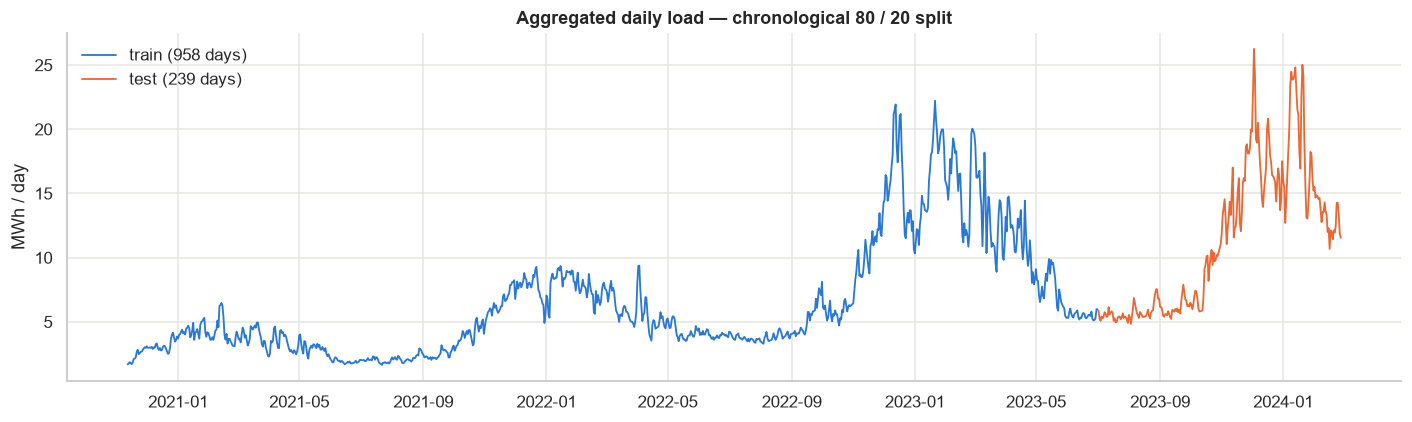

In [87]:
fig, ax = plt.subplots(figsize=(13, 4))
dtr = train.total.groupby(level="day").sum() / 1000
dte = test.total.groupby(level="day").sum() / 1000
ax.plot(dtr.index, dtr, color=C_BLUE, lw=1.2, label=f"train ({len(train_days)} days)")
ax.plot(dte.index, dte, color=C_ORANGE, lw=1.2, label=f"test ({len(test_days)} days)")
ax.set_ylabel("MWh / day"); ax.set_title("Aggregated daily load — chronological 80 / 20 split"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 3. Feature importance analysis
All analyses in this section use **only the training period**: an inner split puts the last 20% of the training
days aside as validation data, so the test set stays untouched.

In [88]:
n_inner_va = int(round(len(train_days) * 0.2))
inner_tr_days, inner_va_days = train_days[:-n_inner_va], train_days[-n_inner_va:]
itr, iva = train.loc[inner_tr_days], train.loc[inner_va_days]
print(f"inner train {inner_tr_days[0]:%Y-%m-%d} → {inner_tr_days[-1]:%Y-%m-%d} | "
      f"inner validation {inner_va_days[0]:%Y-%m-%d} → {inner_va_days[-1]:%Y-%m-%d}")

inner train 2020-11-12 → 2022-12-21 | inner validation 2022-12-22 → 2023-07-01


### 3.1 Correlation with the target

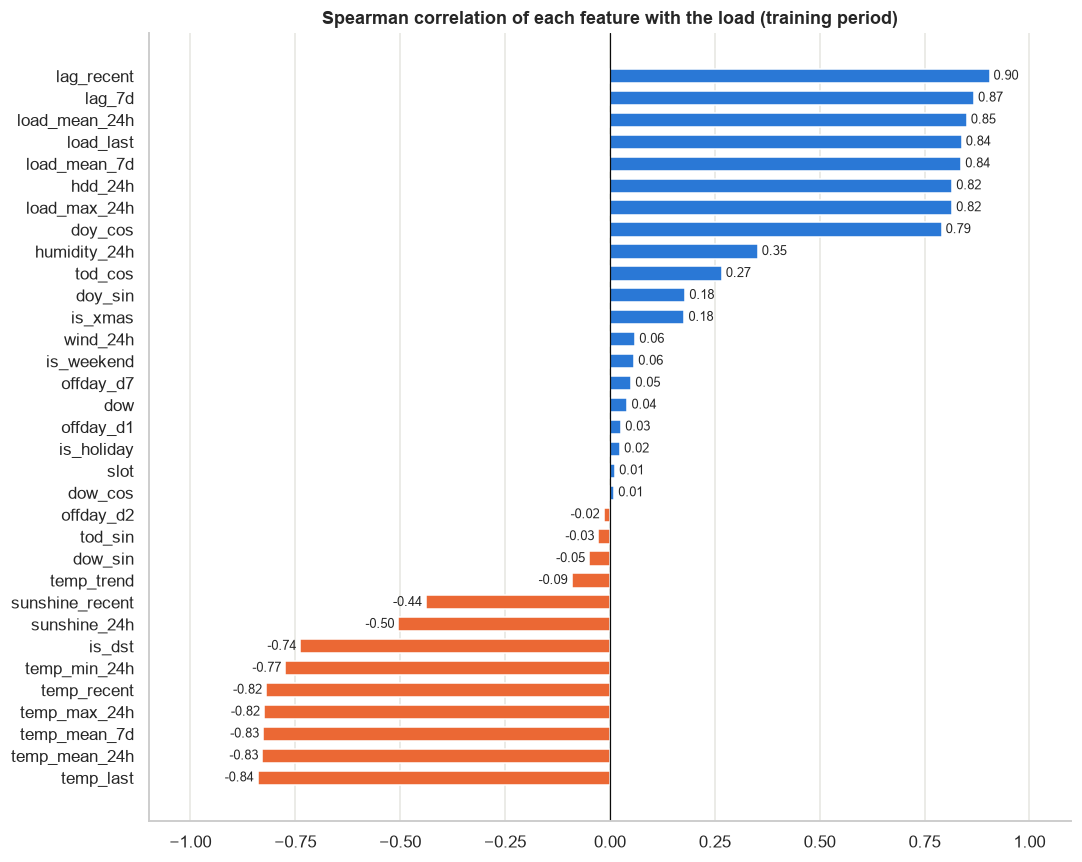

In [89]:
corr = train[FEATURES + ["y"]].corr(method="spearman")["y"].drop("y").sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(corr.index, corr.values, color=[C_ORANGE if v < 0 else C_BLUE for v in corr.values], height=.65)
for i, v in enumerate(corr.values):
    ax.text(v, i, f" {v:.2f} ", va="center", ha="left" if v >= 0 else "right", fontsize=8.5)
ax.axvline(0, color=C_INK, lw=.8); ax.set_xlim(-1.1, 1.1); ax.grid(axis="y", visible=False)
ax.set_title("Spearman correlation of each feature with the load (training period)")
plt.tight_layout(); plt.show()

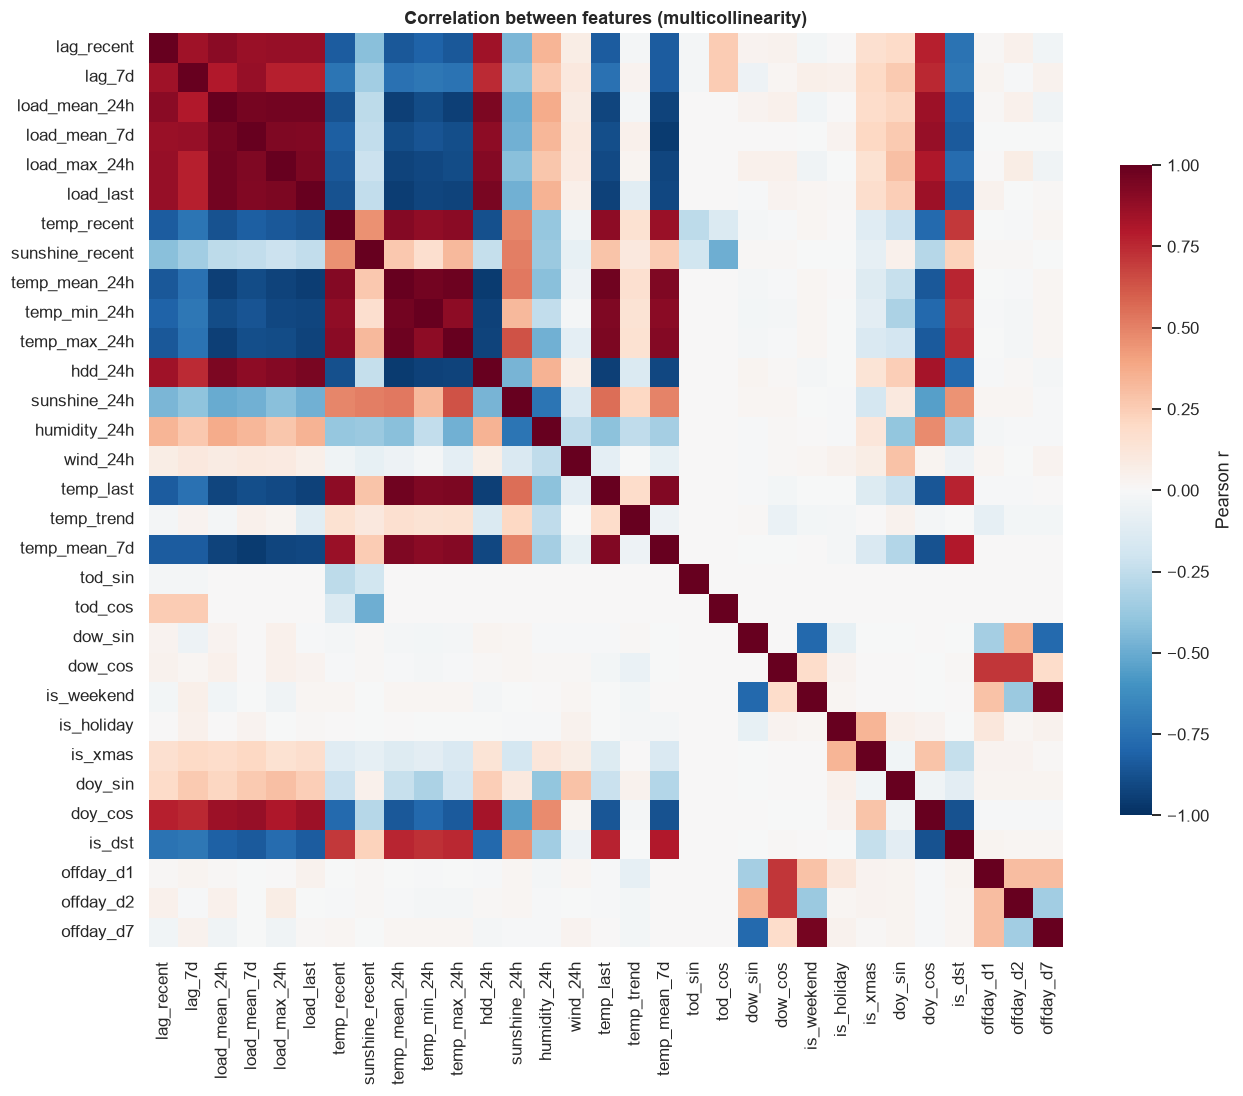

In [90]:
num = [f for f in FEATURES if f not in ("slot", "dow")]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(train[num].corr(), cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, ax=ax,
            cbar_kws={"shrink": .7, "label": "Pearson r"})
ax.set_title("Correlation between features (multicollinearity)")
plt.tight_layout(); plt.show()

The lag features are strongly correlated with each other and with temperature/heating degrees (cold days follow cold
days). This **multicollinearity** makes linear-regression coefficients unstable (→ ridge regularisation) and splits
importance between correlated features in tree models.

### 3.2 Random-forest importance: impurity vs. permutation
*Impurity importance* is computed during training (biased towards high-cardinality features);
*permutation importance* measures how much the validation MAE increases when one feature is shuffled.

Inner-validation MAE of this reference forest: 0.0480 kWh / household / 15 min


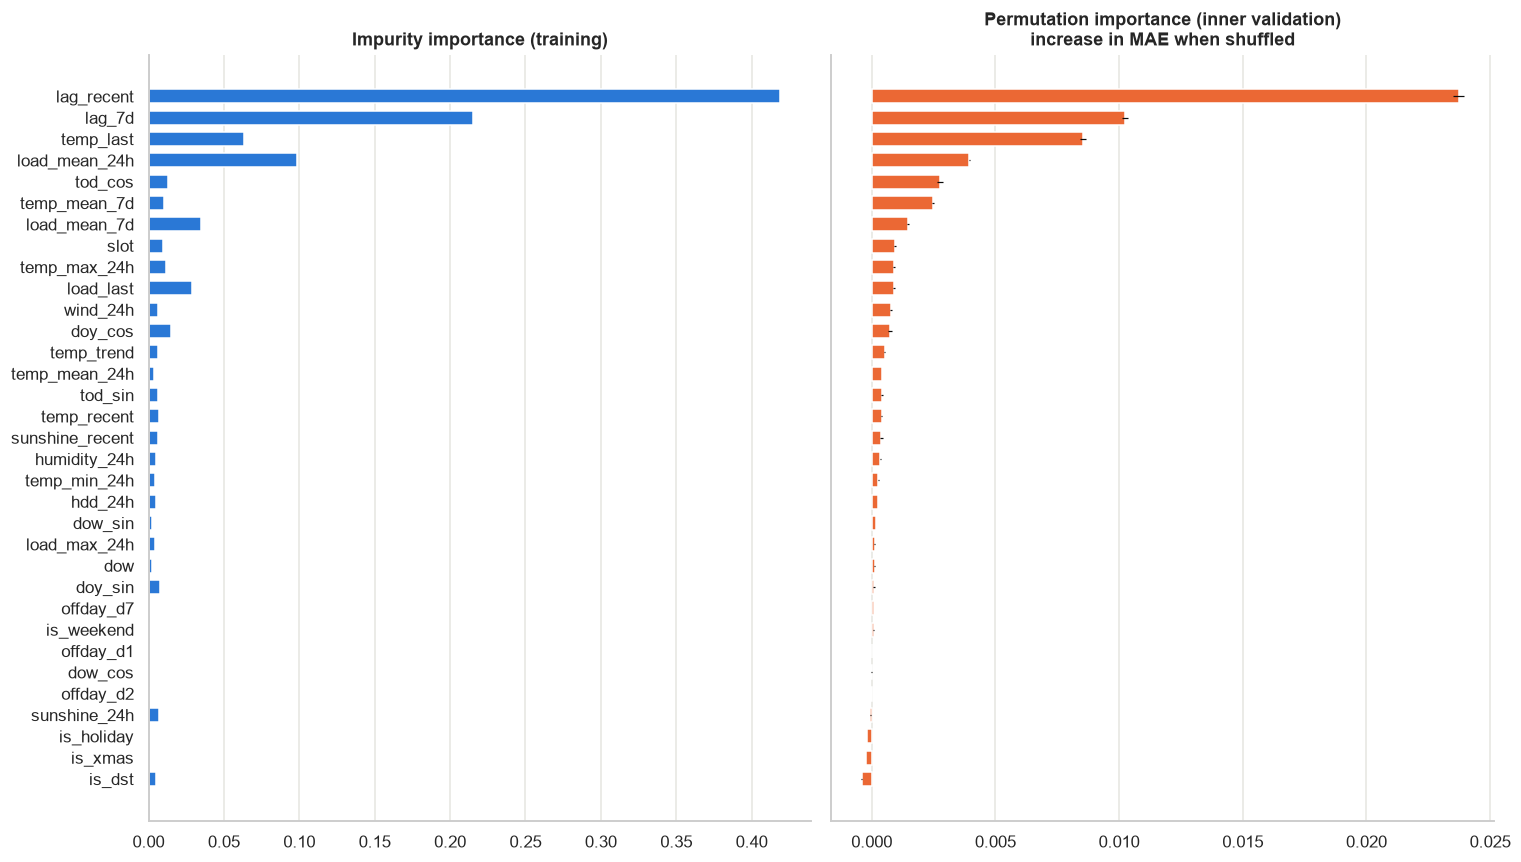

In [91]:
rf_fi = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)
rf_fi.fit(itr[FEATURES], itr.y)
mae_fi = np.abs(rf_fi.predict(iva[FEATURES]) - iva.y).mean()
perm = permutation_importance(rf_fi, iva[FEATURES], iva.y, scoring="neg_mean_absolute_error",
                              n_repeats=5, random_state=SEED)
imp = pd.DataFrame({"impurity": rf_fi.feature_importances_,
                    "permutation_mean": perm.importances_mean, "permutation_std": perm.importances_std},
                   index=FEATURES).sort_values("permutation_mean")
print(f"Inner-validation MAE of this reference forest: {mae_fi:.4f} kWh / household / 15 min")

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
axes[0].barh(imp.index, imp.impurity, color=C_BLUE, height=.65)
axes[0].set_title("Impurity importance (training)")
axes[1].barh(imp.index, imp.permutation_mean, xerr=imp.permutation_std, color=C_ORANGE, height=.65,
             error_kw=dict(ecolor=C_INK, lw=.8))
axes[1].set_title("Permutation importance (inner validation)\nincrease in MAE when shuffled")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 3.3 Linear model: standardised coefficients
Coefficients of a ridge regression on standardised features — the sign shows the direction of the effect,
the magnitude its strength (to be read with care given the multicollinearity above).

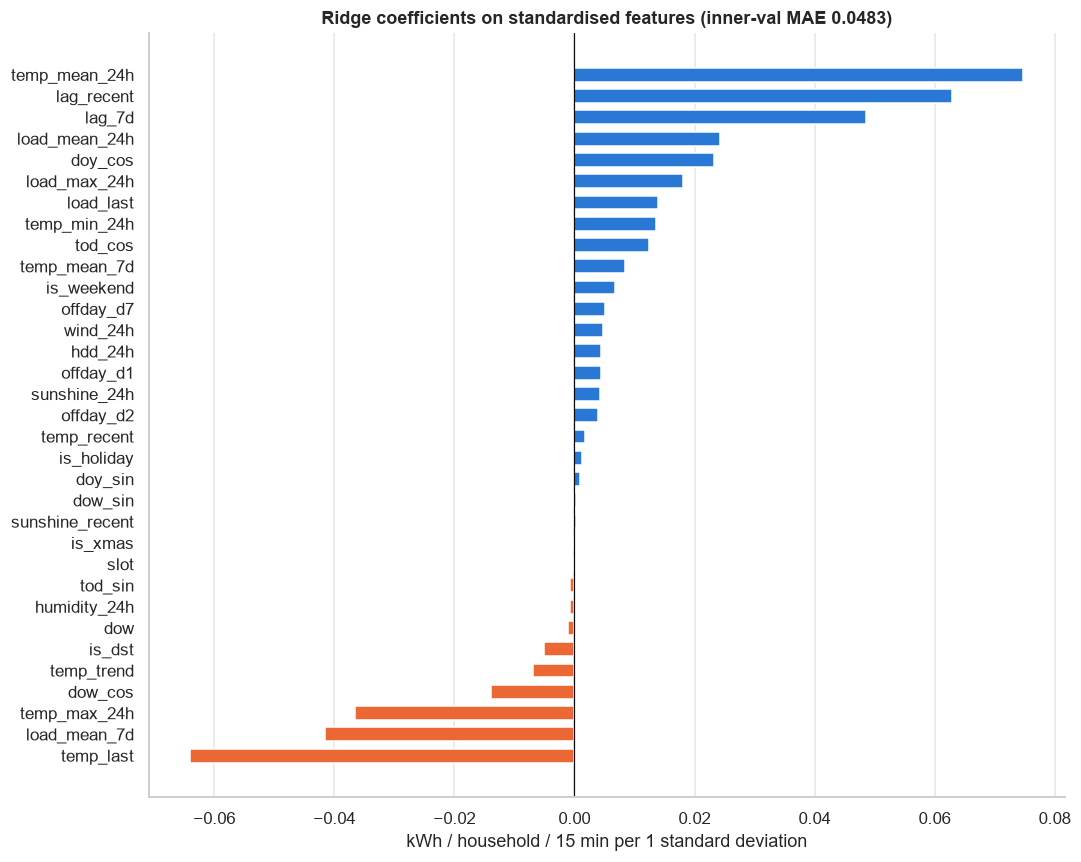

In [92]:
lin_fi = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(itr[FEATURES], itr.y)
coef = pd.Series(lin_fi[-1].coef_, index=FEATURES).sort_values()
mae_lin_fi = np.abs(lin_fi.predict(iva[FEATURES]) - iva.y).mean()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef.index, coef.values, color=[C_ORANGE if v < 0 else C_BLUE for v in coef.values], height=.65)
ax.axvline(0, color=C_INK, lw=.8); ax.grid(axis="y", visible=False)
ax.set_title(f"Ridge coefficients on standardised features (inner-val MAE {mae_lin_fi:.4f})")
ax.set_xlabel("kWh / household / 15 min per 1 standard deviation")
plt.tight_layout(); plt.show()

### 3.4 Importance by feature group
Drop-group experiment: retrain the reference forest without one feature group and measure the change in validation MAE.

,features,inner-val MAE,Δ MAE vs all [%]
model,,,
all features,33,0.0480,0.0000
without load lags,27,0.0513,6.9288
without past weather,21,0.0507,5.5815
without calendar,18,0.0504,5.0621


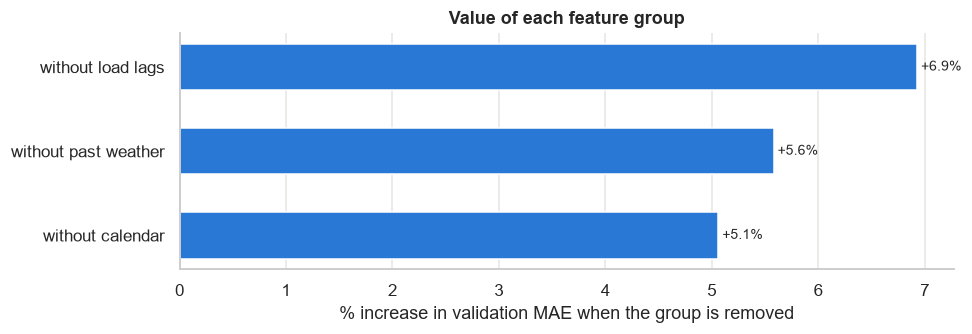

In [93]:
groups = {"load lags": LAG_COLS, "past weather": WX_PAST_COLS, "calendar": CAL_COLS}
rows = [{"model": "all features", "features": len(FEATURES), "inner-val MAE": mae_fi}]
for g, cols in groups.items():
    feats = [f for f in FEATURES if f not in cols]
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)
    m.fit(itr[feats], itr.y)
    rows.append({"model": f"without {g}", "features": len(feats),
                 "inner-val MAE": np.abs(m.predict(iva[feats]) - iva.y).mean()})
grp = pd.DataFrame(rows).set_index("model")
grp["Δ MAE vs all [%]"] = 100 * (grp["inner-val MAE"] / mae_fi - 1)
display(grp)

fig, ax = plt.subplots(figsize=(9, 3.2))
g2 = grp.iloc[1:]["Δ MAE vs all [%]"].sort_values()
ax.barh(g2.index, g2.values, color=C_BLUE, height=.55)
for i, v in enumerate(g2.values):
    ax.text(v, i, f" {v:+.1f}%", va="center", fontsize=9)
ax.set_xlabel("% increase in validation MAE when the group is removed"); ax.grid(axis="y", visible=False)
ax.set_title("Value of each feature group")
plt.tight_layout(); plt.show()

## 4. Hyperparameter optimisation & model training
Shared helpers: metrics, cross-validation with Optuna pruning, parameter persistence, search plots.

In [94]:
BEST_FILE = CACHE / "best_params.json"
best_params = json.loads(BEST_FILE.read_text()) if BEST_FILE.exists() else {}
if not RUN_HPO:
    assert best_params, "RUN_HPO=False needs data/_cache/best_params.json from a previous run"

def save_best():
    BEST_FILE.write_text(json.dumps(best_params, indent=2))

def mae(a, b, w=None):
    return float(np.average(np.abs(np.asarray(a) - np.asarray(b)), weights=w))

# validation errors are weighted with the portfolio size of the day, so the CV error measures the same thing as the
# test metric (error of the aggregated load) instead of giving the small portfolio of 2020/21 the same weight
W_TRAIN = train.n_contract_prev.to_numpy()

def cv_mae(make_model, X, y, feats, trial=None):
    # mean validation MAE over the expanding-window folds; with `trial`, every fold is reported to Optuna for pruning
    scores = []
    for k, (tr, va) in enumerate(folds):
        model = make_model().fit(X.iloc[tr][feats], y[tr])
        scores.append(mae(y[va], model.predict(X.iloc[va][feats]), W_TRAIN[va]))
        if trial is not None:
            trial.report(float(np.mean(scores)), k)
            if trial.should_prune():
                raise optuna.TrialPruned()
    if trial is not None:
        trial.set_user_attr("fold_mae", scores)
    return float(np.mean(scores))

def make_study(pruner):
    # multivariate TPE models interactions between parameters (e.g. learning rate × number of boosting rounds)
    return optuna.create_study(direction="minimize", pruner=pruner,
                               sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=10))

def trials_table(study):
    cols = ["number", "value", "state"] + [f"params_{k}" for k in study.best_params]
    return study.trials_dataframe()[cols].to_dict("list")

def load_trials(key):
    t = pd.DataFrame(best_params[key]).rename(columns=lambda c: c.replace("params_", ""))
    t["value"] = pd.to_numeric(t.value, errors="coerce")
    return t[t.state == "COMPLETE"] if "state" in t else t      # pruned trials only have partial-fold scores

def plot_search(trials, best, title):
    ps = list(best)
    fig, axes = plt.subplots(1, len(ps) + 1, figsize=(3.4 * (len(ps) + 1), 3.6))
    axes[0].plot(trials.number, trials.value, "o", ms=5, color=C_GREY, label="trial")
    axes[0].plot(trials.number, trials.value.cummin(), color=C_BLUE, label="best so far")
    axes[0].set_title("Optimisation history", fontsize=10.5); axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV MAE")
    axes[0].legend(fontsize=8)
    for ax, p in zip(axes[1:], ps):
        ax.scatter(trials[p], trials.value, s=26, color=C_BLUE, alpha=.75, edgecolor="white", linewidth=.6)
        ax.scatter([best[p]], [trials.value.min()], s=60, color=C_ORANGE, zorder=3)
        ax.set_title(p, fontsize=10.5); ax.set_yticklabels([])
    plt.suptitle(f"{title} — hyperparameter search (orange = best, pruned trials not shown)", fontweight="bold")
    plt.tight_layout(); plt.show()

timings = {}

### 4.1 Baselines
No parameters, no training:
* **Baseline (t-7d):** `forecast_total(D, t) = total(D-7, t)`. It captures the weekly rhythm but ignores weather
  changes during the last week.
* **Persistence:** the same quarter-hour of the most recent day known at forecast time (`lag_recent`) × the portfolio
  size of D-1.

Every model has to beat the *better* of the two baselines.

In [95]:
pred_total = {}                                         # model -> (n_test_days, 96) forecast of the aggregated load
actual_total = test.total.to_numpy().reshape(-1, STEPS)
n_contract_test = test.n_contract_prev.to_numpy().reshape(-1, STEPS)     # portfolio size known at forecast time
pred_total["Baseline (t-7d)"] = test.baseline_total.to_numpy().reshape(-1, STEPS)
pred_total["Persistence"] = test.persist_total.to_numpy().reshape(-1, STEPS)
BASELINES = ["Baseline (t-7d)", "Persistence"]
for m in BASELINES:
    print(f"{m} test MAE: {mae(actual_total, pred_total[m]):.2f} kWh per 15 min (aggregated)")

Baseline (t-7d) test MAE: 22.96 kWh per 15 min (aggregated)
Persistence test MAE: 18.95 kWh per 15 min (aggregated)


### 4.2 Linear regression (ridge)
Linear model on all features; `hour` and `day of week` are one-hot encoded so the model can represent the daily
profile, numeric features are standardised. The only hyperparameter is the L2 penalty `alpha`
(`alpha → 0` = ordinary least squares), selected by the expanding-window CV of section 2.6.

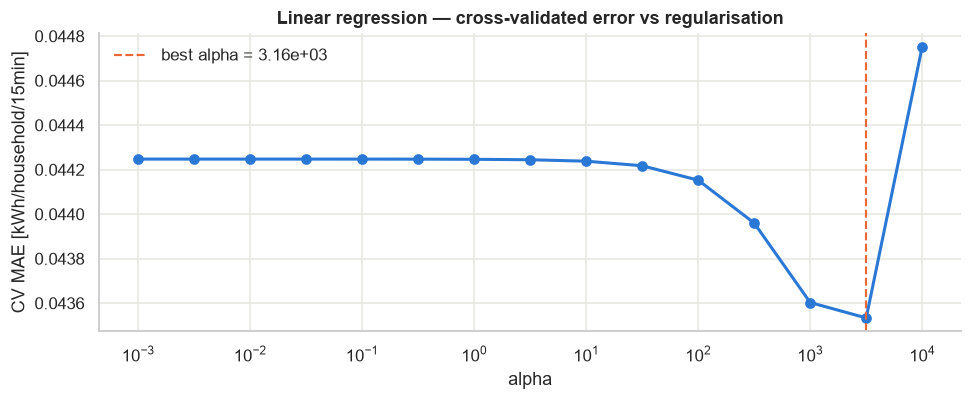

In [96]:
LR_NUM = [f for f in FEATURES if f not in ("slot", "dow")]
LR_CAT = ["hour", "dow"]

def make_lr(alpha):
    pre = ColumnTransformer([("num", StandardScaler(), LR_NUM),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), LR_CAT)])
    return make_pipeline(pre, Ridge(alpha=alpha))

X_train_lr = train[LR_NUM + LR_CAT]
alphas = np.logspace(-3, 4, 15)
if RUN_HPO:
    t0 = time.time()
    lr_cv = pd.Series([cv_mae(lambda a=a: make_lr(a), X_train_lr, y_train, LR_NUM + LR_CAT) for a in alphas], index=alphas)
    best_params["linear"] = {"alpha": float(lr_cv.idxmin())}
    best_params["linear_cv"] = {"alphas": alphas.tolist(), "cv_mae": lr_cv.tolist()}
    save_best()
    timings["linear HPO"] = time.time() - t0
lr_cv = pd.Series(best_params["linear_cv"]["cv_mae"], index=best_params["linear_cv"]["alphas"])

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(lr_cv.index, lr_cv.values, marker="o", ms=6, color=C_BLUE)
ax.axvline(best_params["linear"]["alpha"], color=C_ORANGE, ls="--", lw=1.4, label=f"best alpha = {best_params['linear']['alpha']:.3g}")
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("CV MAE [kWh/household/15min]")
ax.set_title("Linear regression — cross-validated error vs regularisation"); ax.legend()
plt.tight_layout(); plt.show()

t0 = time.time()
lr_model = make_lr(best_params["linear"]["alpha"]).fit(X_train_lr, y_train)
timings["linear fit"] = time.time() - t0
pred_lr = lr_model.predict(test[LR_NUM + LR_CAT]).reshape(-1, STEPS)
pred_total["Linear regression"] = pred_lr * n_contract_test

### 4.3 Random forest
Hyperparameters are searched with **Optuna** (multivariate TPE sampler) minimising the mean MAE over the same
expanding-window folds. Every fold is reported to Optuna, so a trial that is already worse than the median after two
folds is **pruned**. `n_estimators` is not tuned: more trees only reduce variance and never hurt, so the search uses
`RF_TREES_HPO` trees and the final model `RF_TREES_FINAL`.

In [97]:
def rf_from(p, n_estimators=RF_TREES_FINAL):
    return RandomForestRegressor(n_estimators=n_estimators, max_depth=p["max_depth"],
                                 min_samples_leaf=p["min_samples_leaf"], max_features=p["max_features"],
                                 max_samples=p["max_samples"], n_jobs=-1, random_state=SEED)

def rf_objective(trial):
    p = {"max_depth": trial.suggest_int("max_depth", 6, 40),
         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 300, log=True),
         "max_features": trial.suggest_float("max_features", 0.1, 1.0),
         "max_samples": trial.suggest_float("max_samples", 0.2, 1.0)}
    return cv_mae(lambda: rf_from(p, RF_TREES_HPO), X_train, y_train, FEATURES, trial)

if RUN_HPO:
    t0 = time.time()
    rf_study = make_study(optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
    rf_study.enqueue_trial({"max_depth": 20, "min_samples_leaf": 5, "max_features": 0.5, "max_samples": 0.8})
    rf_study.optimize(rf_objective, n_trials=N_TRIALS_RF)
    best_params["random_forest"] = rf_study.best_params
    best_params["random_forest_cv_folds"] = rf_study.best_trial.user_attrs["fold_mae"]
    best_params["random_forest_trials"] = trials_table(rf_study)
    save_best()
    timings["random forest HPO"] = time.time() - t0
    print(f"{N_TRIALS_RF} trials in {timings['random forest HPO'] / 60:.1f} min")

rf_trials = load_trials("random_forest_trials")
print("Best parameters:", best_params["random_forest"])
print("CV MAE per fold of the best trial:", np.round(best_params.get("random_forest_cv_folds", []), 4))
display(rf_trials.sort_values("value").head(8).rename(columns={"value": "CV MAE"}))

30 trials in 6.9 min
Best parameters: {'max_depth': 19, 'min_samples_leaf': 18, 'max_features': 0.5748759151669258, 'max_samples': 0.21412931515477318}
CV MAE per fold of the best trial: [0.0193 0.0513 0.0594 0.0319]


,number,CV MAE,state,max_depth,min_samples_leaf,max_features,max_samples
26,26,0.0405,COMPLETE,19,18,0.5749,0.2141
10,10,0.0406,COMPLETE,20,15,0.5676,0.2043
22,22,0.0407,COMPLETE,19,16,0.5094,0.2022
11,11,0.0407,COMPLETE,18,20,0.4262,0.2015
28,28,0.0407,COMPLETE,29,12,0.4761,0.2497
5,5,0.0407,COMPLETE,16,14,0.4888,0.4330
4,4,0.0409,COMPLETE,35,2,0.2636,0.3467
21,21,0.0409,COMPLETE,13,33,0.3562,0.4420


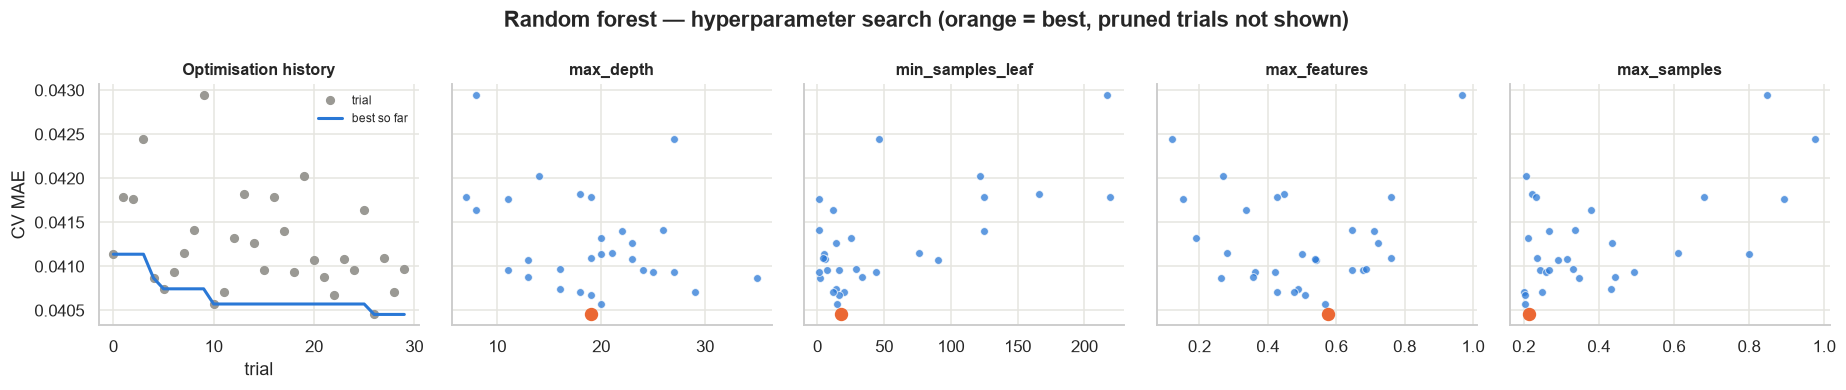

In [98]:
plot_search(rf_trials, best_params["random_forest"], "Random forest")

In [99]:
t0 = time.time()
rf_model = rf_from(best_params["random_forest"]).fit(X_train, y_train)
timings["random forest fit"] = time.time() - t0
pred_rf = rf_model.predict(X_test).reshape(-1, STEPS)
pred_total["Random forest"] = pred_rf * n_contract_test

print(f"Random forest trained in {timings['random forest fit']:.0f}s")

Random forest trained in 9s


### 4.4 Gradient boosting
Histogram gradient boosting (scikit-learn's LightGBM-style implementation) is usually the strongest model for tabular
load forecasting. It is searched with the same CV and pruning as the random forest. The loss is part of the search:
`absolute_error` optimises the evaluated MAE directly. `early_stopping` is switched off on purpose — scikit-learn would
hold out a *random* 10% of the rows, i.e. quarter-hours of the same days as the training rows; the number of boosting
rounds (`max_iter`) is tuned by the time-series CV instead.

40 trials in 45.1 min
Best parameters: {'loss': 'absolute_error', 'learning_rate': 0.02776842132022208, 'max_iter': 997, 'max_leaf_nodes': 44, 'min_samples_leaf': 762, 'l2_regularization': 0.016636717292368396}
CV MAE per fold of the best trial: [0.018  0.0526 0.0557 0.0284]


,number,CV MAE,state,loss,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization
24,24,0.0387,COMPLETE,absolute_error,0.0278,997,44,762,0.0166
39,39,0.0388,COMPLETE,absolute_error,0.0234,879,60,975,0.0024
34,34,0.0388,COMPLETE,absolute_error,0.0379,915,33,864,0.0007
26,26,0.0389,COMPLETE,absolute_error,0.0233,927,53,965,0.0030
31,31,0.0389,COMPLETE,absolute_error,0.0262,957,53,754,0.0004
32,32,0.0389,COMPLETE,absolute_error,0.0281,728,44,867,0.0012
27,27,0.0390,COMPLETE,absolute_error,0.0224,730,39,456,0.0613
35,35,0.0390,COMPLETE,absolute_error,0.0414,984,30,795,0.0019


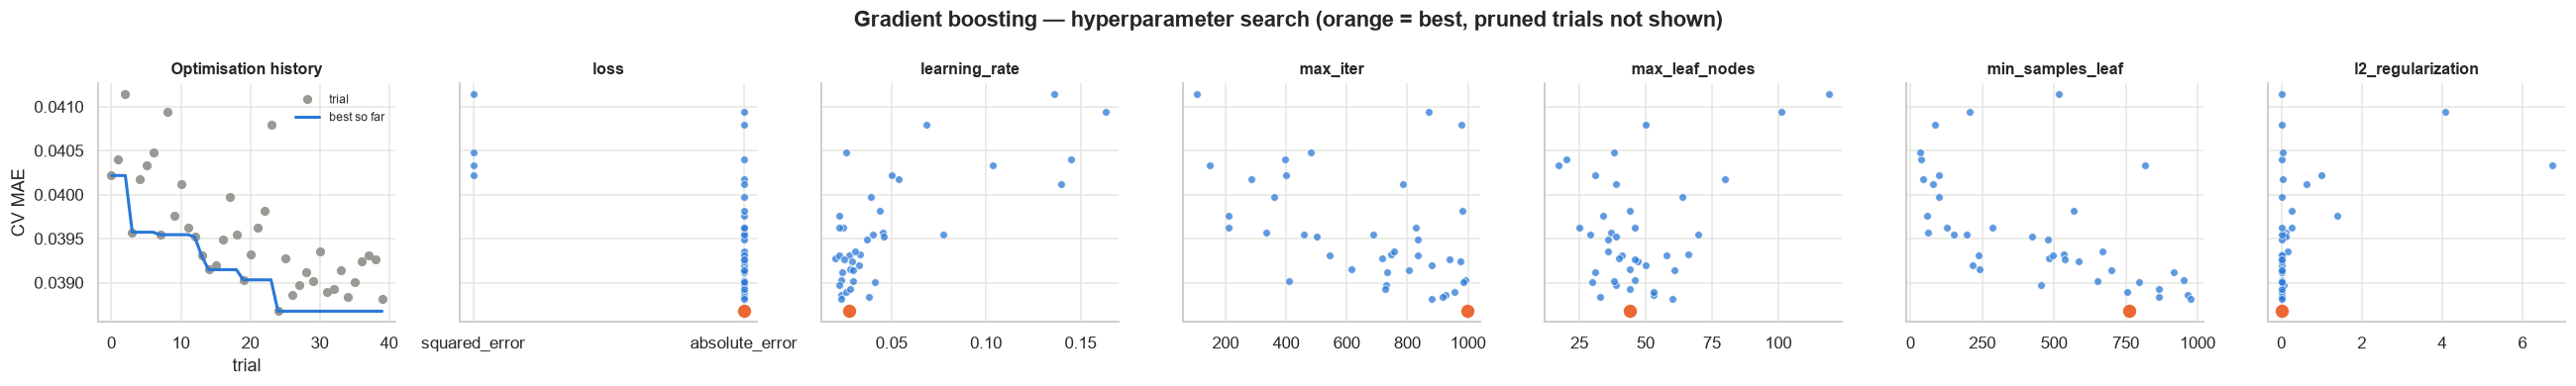

Gradient boosting trained in 27s


In [100]:
def gb_from(p):
    return HistGradientBoostingRegressor(loss=p["loss"], learning_rate=p["learning_rate"], max_iter=p["max_iter"],
                                         max_leaf_nodes=p["max_leaf_nodes"], min_samples_leaf=p["min_samples_leaf"],
                                         l2_regularization=p["l2_regularization"], early_stopping=False,
                                         random_state=SEED)

def gb_objective(trial):
    p = {"loss": trial.suggest_categorical("loss", ["squared_error", "absolute_error"]),
         "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
         "max_iter": trial.suggest_int("max_iter", 100, 1000, log=True),
         "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 127, log=True),
         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 1000, log=True),
         "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True)}
    return cv_mae(lambda: gb_from(p), X_train, y_train, FEATURES, trial)

if RUN_HPO or "gradient_boosting" not in best_params:
    t0 = time.time()
    gb_study = make_study(optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
    gb_study.enqueue_trial({"loss": "squared_error", "learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31,
                            "min_samples_leaf": 100, "l2_regularization": 1.0})
    gb_study.optimize(gb_objective, n_trials=N_TRIALS_GB)
    best_params["gradient_boosting"] = gb_study.best_params
    best_params["gradient_boosting_cv_folds"] = gb_study.best_trial.user_attrs["fold_mae"]
    best_params["gradient_boosting_trials"] = trials_table(gb_study)
    save_best()
    timings["gradient boosting HPO"] = time.time() - t0
    print(f"{N_TRIALS_GB} trials in {timings['gradient boosting HPO'] / 60:.1f} min")

gb_trials = load_trials("gradient_boosting_trials")
print("Best parameters:", best_params["gradient_boosting"])
print("CV MAE per fold of the best trial:", np.round(best_params["gradient_boosting_cv_folds"], 4))
display(gb_trials.sort_values("value").head(8).rename(columns={"value": "CV MAE"}))
plot_search(gb_trials, best_params["gradient_boosting"], "Gradient boosting")

t0 = time.time()
gb_model = gb_from(best_params["gradient_boosting"]).fit(X_train, y_train)
timings["gradient boosting fit"] = time.time() - t0
pred_gb = gb_model.predict(X_test).reshape(-1, STEPS)
pred_total["Gradient boosting"] = pred_gb * n_contract_test
print(f"Gradient boosting trained in {timings['gradient boosting fit']:.0f}s")

### 4.5 LSTM (sequence-to-sequence)
**Architecture**
* **Encoder LSTM** runs over the **last 7 × 24 h known at forecast time, one step per 24-h block**. Each step sees the
  24 hourly loads and 24 hourly temperatures of that block and its share of weekend/holiday hours
  (with `METER_SLOT_D1 = STEPS` the blocks are exactly the calendar days D-7 … D-1).
* **Decoder LSTM** starts from the encoder's final state and runs over the **24 hours of day D**. Each step receives
  the features of its four quarter-hours (the same features as the tabular models: load lags, past weather,
  calendar of day D).
* A linear head turns every decoder step into **4 quarter-hour values** → 24 × 4 = 96 outputs in one shot
  (no recursive error accumulation).

Why not one recurrent step per quarter-hour? 7 × 96 + 96 = 768 sequential steps are ~20× slower to train on a CPU
for the same information; 7 + 24 = 31 steps keep the hyperparameter search feasible.

All inputs and the target are standardised with training statistics. Loss = **L1** (the MAE that is evaluated),
optimiser = Adam, early stopping.

In [101]:
DEC_COLS = [f for f in FEATURES if f not in ("slot", "dow")]
T_FLAT = WX_FLAT["temp"]
OFF_FLAT = np.repeat(offday.to_numpy(), STEPS)
ENC_LEN = 7 * STEPS                                                            # encoder window: 7 × 24 h
day_pos_all = pd.Series(np.arange(N_DAYS), index=day_index)

def build_arrays(days):
    P = day_pos_all.reindex(days).to_numpy()
    end = (P - 1) * STEPS + METER_SLOT_D1                  # flat position of the first quarter-hour NOT known yet
    assert (end - ENC_LEN >= 0).all(), "history window reaches before the start of the modelling period"
    win = end[:, None] + np.arange(-ENC_LEN, 0)[None, :]   # (n, 672) known history, chronological, last = newest
    load_h = H_FLAT[win].reshape(len(P), 7, 24, 4).mean(-1)                   # hourly mean load per 24-h block
    temp_h = T_FLAT[win].reshape(len(P), 7, 24, 4).mean(-1)                   # weather is known at least as long
    off = OFF_FLAT[win].reshape(len(P), 7, STEPS).mean(-1, keepdims=True)     # share of weekend/holiday quarter-hours
    enc = np.concatenate([load_h, temp_h, off], axis=-1)                      # (n, 7, 49)
    sub = data.loc[days]
    dec = sub[DEC_COLS].to_numpy().reshape(len(P), 24, 4 * len(DEC_COLS))     # (n, 24, 4·F)
    y = sub.y.to_numpy().reshape(len(P), STEPS)                               # (n, 96)
    assert np.isfinite(enc).all() and np.isfinite(dec).all() and np.isfinite(y).all()
    return enc, dec, y

class Scalers:
    # per-feature standardisation fitted on training days only
    def __init__(self, enc, dec, y):
        e, d = enc.reshape(-1, enc.shape[-1]), dec.reshape(-1, dec.shape[-1])
        self.e_mu, self.e_sd = e.mean(0), e.std(0) + 1e-8
        self.d_mu, self.d_sd = d.mean(0), d.std(0) + 1e-8
        self.y_mu, self.y_sd = y.mean(), y.std()
    def transform(self, enc, dec, y=None):
        out = [torch.tensor((enc - self.e_mu) / self.e_sd, dtype=torch.float32),
               torch.tensor((dec - self.d_mu) / self.d_sd, dtype=torch.float32)]
        if y is not None:
            out.append(torch.tensor((y - self.y_mu) / self.y_sd, dtype=torch.float32))
        return out
    def inverse_y(self, y_scaled):
        return y_scaled * self.y_sd + self.y_mu

class Seq2SeqLSTM(nn.Module):
    def __init__(self, n_enc, n_dec, hidden, layers, dropout):
        super().__init__()
        drop = dropout if layers > 1 else 0.0
        self.encoder = nn.LSTM(n_enc, hidden, layers, batch_first=True, dropout=drop)
        self.decoder = nn.LSTM(n_dec, hidden, layers, batch_first=True, dropout=drop)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 4))
    def forward(self, x_enc, x_dec):
        _, state = self.encoder(x_enc)                                         # summary of the last 7 × 24 h
        out, _ = self.decoder(x_dec, state)                                    # (batch, 24, hidden)
        return self.head(out).reshape(len(x_enc), -1)                          # (batch, 96)

def predict_lstm(model, tensors, scalers):
    model.eval()
    with torch.no_grad():
        return scalers.inverse_y(model(tensors[0], tensors[1]).numpy())

def fit_lstm(p, tr, scalers, va=None, epochs=LSTM_MAX_EPOCHS, seed=SEED, trial=None):
    # tr / va: lists of tensors [enc, dec, y_scaled]; va additionally needs y in kWh for the MAE
    torch.manual_seed(seed)
    model = Seq2SeqLSTM(tr[0].shape[-1], tr[1].shape[-1], p["hidden"], p["layers"], p["dropout"])
    opt = torch.optim.Adam(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    loader = DataLoader(TensorDataset(*tr), batch_size=p["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    loss_fn, hist, best, best_state, best_ep, wait = nn.L1Loss(), [], np.inf, None, epochs, 0
    for ep in range(epochs):
        model.train()
        tr_loss = 0.0
        for xe, xd, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xe, xd), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(yb)
        rec = {"epoch": ep + 1, "train_loss": tr_loss / len(tr[0])}
        if va is not None:
            rec["val_mae"] = mae(predict_lstm(model, va, scalers), va[3])
            if rec["val_mae"] < best - 1e-6:
                best, best_state, best_ep, wait = rec["val_mae"], copy.deepcopy(model.state_dict()), ep + 1, 0
            else:
                wait += 1
            if trial is not None:
                trial.report(rec["val_mae"], ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
        hist.append(rec)
        if va is not None and wait >= LSTM_PATIENCE:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best_ep

enc_tr, dec_tr, ylstm_tr = build_arrays(train_days)
enc_te, dec_te, ylstm_te = build_arrays(test_days)
print("encoder input", enc_tr.shape, "| decoder input", dec_tr.shape, "| target", ylstm_tr.shape)

encoder input (958, 7, 49) | decoder input (958, 24, 124) | target (958, 96)


**Hyperparameter search.** Training an LSTM is expensive, so instead of the CV folds the search uses the inner split
(last 20% of the training days as validation) with early stopping and Optuna's median pruner, which stops
unpromising trials early. The number of epochs of the best trial is reused for the final training on all training days.

Note: the LSTM is selected on a different, single validation period than the other models, and early stopping and
model selection use the same days — its validation MAE is optimistic and not comparable with their CV MAE.

In [102]:
in_tr = np.isin(train_days, inner_tr_days)
sc_inner = Scalers(enc_tr[in_tr], dec_tr[in_tr], ylstm_tr[in_tr])
T_in_tr = sc_inner.transform(enc_tr[in_tr], dec_tr[in_tr], ylstm_tr[in_tr])
T_in_va = sc_inner.transform(enc_tr[~in_tr], dec_tr[~in_tr]) + [None, ylstm_tr[~in_tr]]

def lstm_objective(trial):
    p = {"hidden": trial.suggest_categorical("hidden", [32, 64, 128]),
         "layers": trial.suggest_int("layers", 1, 2),
         "dropout": trial.suggest_float("dropout", 0.0, 0.4),
         "lr": trial.suggest_float("lr", 3e-4, 5e-3, log=True),
         "batch": trial.suggest_categorical("batch", [16, 32, 64]),
         "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)}
    _, hist, best_ep = fit_lstm(p, T_in_tr, sc_inner, va=T_in_va, trial=trial)
    trial.set_user_attr("epochs", int(best_ep))
    trial.set_user_attr("curve", {"train": hist.train_loss.tolist(), "val": hist.val_mae.tolist()})
    return float(hist.val_mae.min())

if RUN_HPO:
    t0 = time.time()
    lstm_study = make_study(optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
    lstm_study.enqueue_trial({"hidden": 64, "layers": 1, "dropout": 0.1, "lr": 1e-3, "batch": 32, "weight_decay": 1e-5})
    lstm_study.optimize(lstm_objective, n_trials=N_TRIALS_LSTM)
    best_params["lstm"] = {**lstm_study.best_params, "epochs": lstm_study.best_trial.user_attrs["epochs"]}
    best_params["lstm_curve"] = lstm_study.best_trial.user_attrs["curve"]
    tdf = lstm_study.trials_dataframe()
    tdf["epochs"] = tdf.get("user_attrs_epochs")
    best_params["lstm_trials"] = tdf[["number", "value", "state", "epochs"] + [f"params_{k}" for k in lstm_study.best_params]].astype(str).to_dict("list")
    save_best()
    timings["LSTM HPO"] = time.time() - t0
    print(f"{N_TRIALS_LSTM} trials in {timings['LSTM HPO'] / 60:.1f} min")

lstm_trials = pd.DataFrame(best_params["lstm_trials"]).rename(columns=lambda c: c.replace("params_", ""))
lstm_trials["value"] = pd.to_numeric(lstm_trials.value, errors="coerce")
print("Best parameters:", best_params["lstm"])
print(f"{(lstm_trials.state == 'PRUNED').sum()} of {len(lstm_trials)} trials pruned")
display(lstm_trials[lstm_trials.state == "COMPLETE"].sort_values("value").head(8).rename(columns={"value": "val MAE"}))

30 trials in 8.4 min
Best parameters: {'hidden': 128, 'layers': 1, 'dropout': 0.11237380387495231, 'lr': 0.0013810639383939022, 'batch': 32, 'weight_decay': 0.0008862326508576246, 'epochs': 32}
3 of 30 trials pruned


,number,val MAE,state,epochs,hidden,layers,dropout,lr,batch,weight_decay
7,7,0.0439,COMPLETE,32.0,128,1,0.11237380387495231,0.0013810639383939022,32,0.0008862326508576246
26,26,0.0441,COMPLETE,8.0,128,1,0.0038551872681156507,0.0017769396064661333,16,5.9259434615533513e-05
21,21,0.0441,COMPLETE,8.0,128,1,0.1548467634046957,0.0012933248662847085,16,0.0002364765298025526
23,23,0.0442,COMPLETE,14.0,128,1,0.31241909210084623,0.0009819879461202858,16,0.00010050538112793382
24,24,0.0445,COMPLETE,8.0,128,1,0.19201912300977292,0.0014612585875318038,16,0.00011692076407325454
16,16,0.0446,COMPLETE,39.0,128,1,0.2966032128752153,0.0035983840628500893,32,0.0002241407432075264
29,29,0.0446,COMPLETE,8.0,128,1,0.11997882990420161,0.001855606199137836,16,4.581129413053291e-05
12,12,0.0448,COMPLETE,14.0,128,1,0.15166231888686027,0.002454100989026408,32,0.0007917336109217939


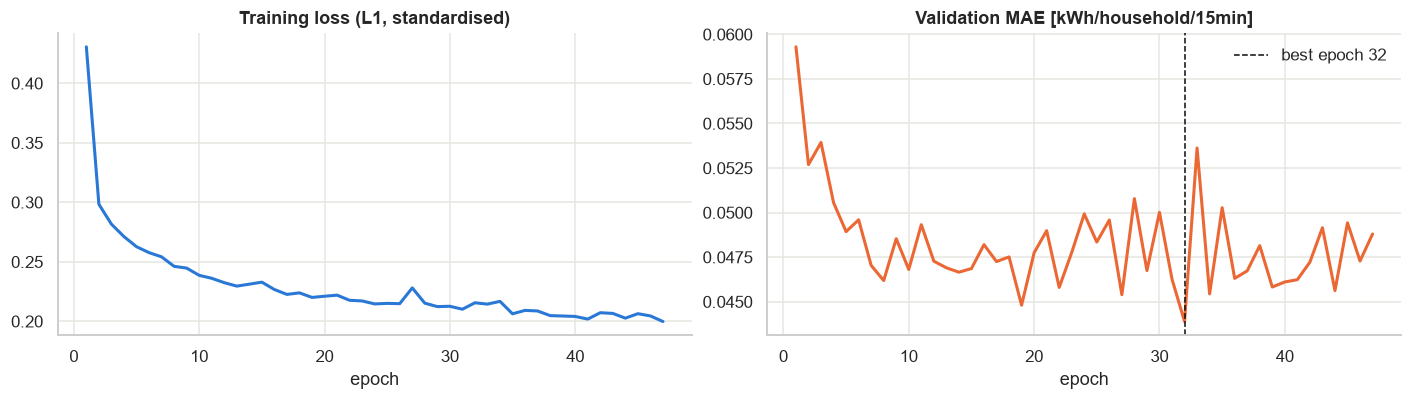

In [103]:
# learning curve of the best trial (inner split)
p_best = best_params["lstm"]
curve = best_params["lstm_curve"]
epochs_axis = np.arange(1, len(curve["val"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(epochs_axis, curve["train"], color=C_BLUE)
axes[0].set_title("Training loss (L1, standardised)"); axes[0].set_xlabel("epoch")
axes[1].plot(epochs_axis, curve["val"], color=C_ORANGE)
axes[1].axvline(p_best["epochs"], color=C_INK, ls="--", lw=1, label=f"best epoch {p_best['epochs']}")
axes[1].set_title("Validation MAE [kWh/household/15min]"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()
if p_best["epochs"] >= LSTM_MAX_EPOCHS:
    print("Warning: best epoch = LSTM_MAX_EPOCHS -> the LSTM has not converged, increase LSTM_MAX_EPOCHS")

In [104]:
# final LSTM: train on all training days for the selected number of epochs, average several seeds
sc_full = Scalers(enc_tr, dec_tr, ylstm_tr)
T_tr = sc_full.transform(enc_tr, dec_tr, ylstm_tr)
T_te = sc_full.transform(enc_te, dec_te)
t0 = time.time()
lstm_models = [fit_lstm(p_best, T_tr, sc_full, epochs=p_best["epochs"], seed=SEED + k)[0] for k in range(LSTM_ENSEMBLE)]
timings["LSTM fit"] = time.time() - t0
pred_lstm = np.mean([predict_lstm(m, T_te, sc_full) for m in lstm_models], axis=0)
pred_total["LSTM"] = pred_lstm * n_contract_test
print(f"Trained {LSTM_ENSEMBLE} LSTM(s) for {p_best['epochs']} epochs in {timings['LSTM fit']:.0f}s")

Trained 3 LSTM(s) for 32 epochs in 47s


## 5. Validation on the test period (last 20%)
All forecasts are for the **aggregated load of all households** in kWh per 15 min, issued at the day-ahead gate
closure on the previous day.

| Metric | Meaning |
|---|---|
| MAE / RMSE | mean absolute / root-mean-square error per quarter-hour (kWh) |
| nMAE | MAE relative to the mean load (%) |
| MAPE | mean absolute percentage error per quarter-hour |
| R² | explained variance |
| Bias | mean error relative to mean load (+ = over-forecast) |
| Daily energy error | abs. error of the day's total energy (what is bought on the day-ahead market), % |
| Daily peak error | abs. error of the day's maximum quarter-hour load, % |
| Skill vs best baseline | 1 − MAE / MAE(better of the two baselines) |

In [105]:
def evaluate(y, p):
    e = p - y
    return {"MAE [kWh]": np.abs(e).mean(), "RMSE [kWh]": np.sqrt((e ** 2).mean()),
            "nMAE [%]": 100 * np.abs(e).mean() / y.mean(), "MAPE [%]": 100 * np.mean(np.abs(e) / y),
            "R²": r2_score(y.ravel(), p.ravel()), "Bias [%]": 100 * e.mean() / y.mean(),
            "Daily energy error [%]": 100 * np.mean(np.abs(e.sum(1)) / y.sum(1)),
            "Daily peak error [%]": 100 * np.mean(np.abs(p.max(1) - y.max(1)) / y.max(1))}

MODELS = list(pred_total)
res = pd.DataFrame({m: evaluate(actual_total, pred_total[m]) for m in MODELS}).T
res["Skill vs best baseline [%]"] = 100 * (1 - res["MAE [kWh]"] / res.loc[BASELINES, "MAE [kWh]"].min())
display(res.style.format("{:.2f}").format("{:.3f}", subset=["R²"])
        .background_gradient(cmap="Blues_r", subset=["nMAE [%]", "Daily energy error [%]"]))

,MAE [kWh],RMSE [kWh],nMAE [%],MAPE [%],R²,Bias [%],Daily energy error [%],Daily peak error [%],Skill vs best baseline [%]
Baseline (t-7d),22.96,34.03,19.48,18.14,0.716,-1.88,14.36,12.29,-21.14
Persistence,18.95,27.66,16.08,16.14,0.813,-0.44,10.33,9.73,0.00
Linear regression,16.06,21.95,13.63,15.04,0.882,2.82,10.01,9.45,15.26
Random forest,14.98,21.10,12.72,13.41,0.891,2.48,9.06,8.08,20.92
Gradient boosting,14.45,20.43,12.26,12.78,0.898,3.11,8.85,7.40,23.73
LSTM,14.83,21.04,12.59,13.21,0.892,3.29,8.96,7.38,21.72


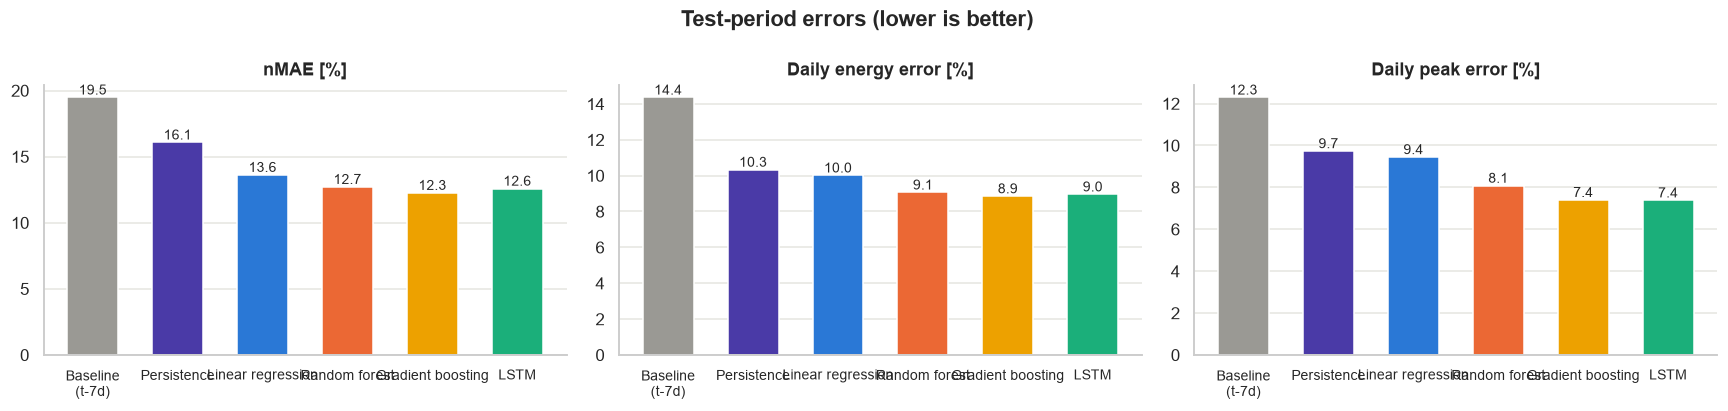

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, col in zip(axes, ["nMAE [%]", "Daily energy error [%]", "Daily peak error [%]"]):
    v = res.loc[MODELS, col]
    ax.bar(range(len(v)), v.values, color=[MODEL_COLORS[m] for m in MODELS], width=.6)
    for i, x in enumerate(v.values):
        ax.text(i, x, f"{x:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(v)), [m.replace(" (", "\n(") for m in MODELS], fontsize=9)
    ax.set_title(col); ax.grid(axis="x", visible=False)
plt.suptitle("Test-period errors (lower is better)", fontweight="bold")
plt.tight_layout(); plt.show()

### 5.1 Are the differences significant?
About 240 test days are not many, and consecutive days are correlated. A **moving-block bootstrap** over the test days
(blocks of 7 days) gives a 95% interval for the MAE difference of every model to the best one. If the interval
contains 0, the test period cannot tell the two models apart.

In [107]:
rng = np.random.default_rng(SEED)
B, L = 2000, 7
n_days = len(test_days)
starts = rng.integers(0, n_days - L + 1, size=(B, int(np.ceil(n_days / L))))
boot_idx = (starts[:, :, None] + np.arange(L)).reshape(B, -1)[:, :n_days]     # B resamples of the test days, 7-day blocks
day_mae = {m: np.abs(pred_total[m] - actual_total).mean(1) for m in MODELS}
best_m = res.loc[MODELS, "MAE [kWh]"].idxmin()
sig = {}
for m in MODELS:
    diff = day_mae[m] - day_mae[best_m]
    boot = diff[boot_idx].mean(1)
    sig[m] = {"Δ MAE vs best [kWh]": diff.mean(), "95% CI low": np.percentile(boot, 2.5),
              "95% CI high": np.percentile(boot, 97.5), "P(better than best)": (boot < 0).mean()}
print(f"Best model on the test period: {best_m}")
display(pd.DataFrame(sig).T.round(3))

Best model on the test period: Gradient boosting


,Δ MAE vs best [kWh],95% CI low,95% CI high,P(better than best)
Baseline (t-7d),8.5030,4.9310,12.9490,0.0000
Persistence,4.4970,2.9440,6.2250,0.0000
Linear regression,1.6050,0.7070,2.5380,0.0000
Random forest,0.5320,0.0910,0.9760,0.0090
Gradient boosting,0.0000,0.0000,0.0000,0.0000
LSTM,0.3810,-0.5440,1.1940,0.2200


### 5.2 Generalisation check: training vs test error
A large gap between training and test error indicates over-fitting. For the tree ensembles the in-sample error is
optimistic by construction (every tree has seen most training rows) — compare their test error with the CV error of
section 4 instead.

In [108]:
actual_tr = train.total.to_numpy().reshape(-1, STEPS)
nc_tr = train.n_contract_prev.to_numpy().reshape(-1, STEPS)
in_sample = {
    "Baseline (t-7d)": train.baseline_total.to_numpy().reshape(-1, STEPS),
    "Persistence": train.persist_total.to_numpy().reshape(-1, STEPS),
    "Linear regression": lr_model.predict(train[LR_NUM + LR_CAT]).reshape(-1, STEPS) * nc_tr,
    "Random forest": rf_model.predict(X_train).reshape(-1, STEPS) * nc_tr,
    "Gradient boosting": gb_model.predict(X_train).reshape(-1, STEPS) * nc_tr,
    "LSTM": np.mean([predict_lstm(m, T_tr, sc_full) for m in lstm_models], axis=0) * nc_tr,
}
gap = pd.DataFrame({"train nMAE [%]": {m: evaluate(actual_tr, p)["nMAE [%]"] for m, p in in_sample.items()},
                    "test nMAE [%]": res.loc[MODELS, "nMAE [%]"]})
gap["gap [pp]"] = gap["test nMAE [%]"] - gap["train nMAE [%]"]
display(gap.round(2))

,train nMAE [%],test nMAE [%],gap [pp]
Baseline (t-7d),20.1300,19.4800,-0.6500
Persistence,16.4800,16.0800,-0.4000
Linear regression,13.9400,13.6300,-0.3200
Random forest,9.0600,12.7200,3.6500
Gradient boosting,6.5400,12.2600,5.7200
LSTM,9.3500,12.5900,3.2400


### 5.3 Example forecasts
Forecasts for four characteristic test days (coldest, a mild day, the warmest, and Christmas Day if it is in the test
period) and for a two-week stretch. The temperature in the titles is the *measured* mean of the target day — used
only to pick and label the days, it was not available to the models.

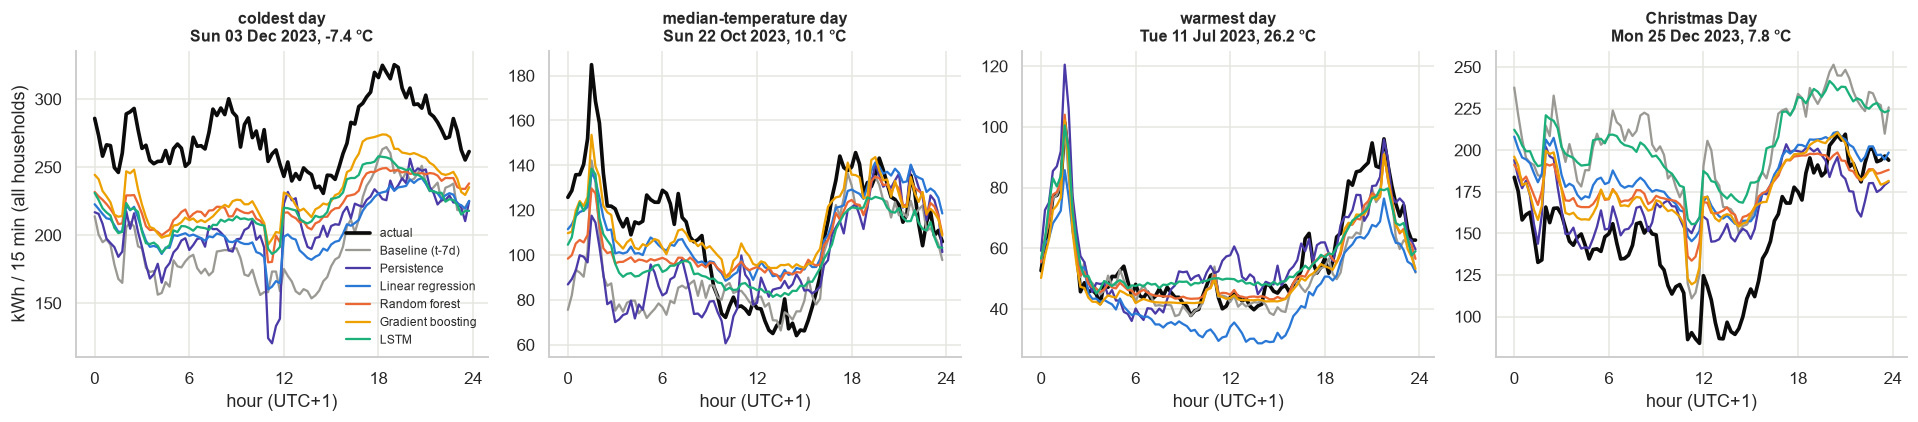

In [109]:
test_temp = Wx["temp"].mean(axis=1).reindex(test_days)        # evaluation only — not a model input
picks = {"coldest day": test_temp.idxmin(), "median-temperature day": (test_temp - test_temp.median()).abs().idxmin(),
         "warmest day": test_temp.idxmax()}
xmas = [d for d in test_days if d.month == 12 and d.day == 25]
if xmas:
    picks["Christmas Day"] = xmas[0]
hours = np.arange(STEPS) / 4
fig, axes = plt.subplots(1, len(picks), figsize=(4.4 * len(picks), 4), sharey=False)
for ax, (label, d) in zip(np.atleast_1d(axes), picks.items()):
    i = test_days.get_loc(d)
    ax.plot(hours, actual_total[i], color=C_INK, lw=2.4, label="actual")
    for m in MODELS:
        ax.plot(hours, pred_total[m][i], color=MODEL_COLORS[m], lw=1.5, label=m)
    ax.set_title(f"{label}\n{d:%a %d %b %Y}, {test_temp[d]:.1f} °C", fontsize=10.5)
    ax.set_xticks(range(0, 25, 6)); ax.set_xlabel("hour (UTC+1)")
np.atleast_1d(axes)[0].set_ylabel("kWh / 15 min (all households)")
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

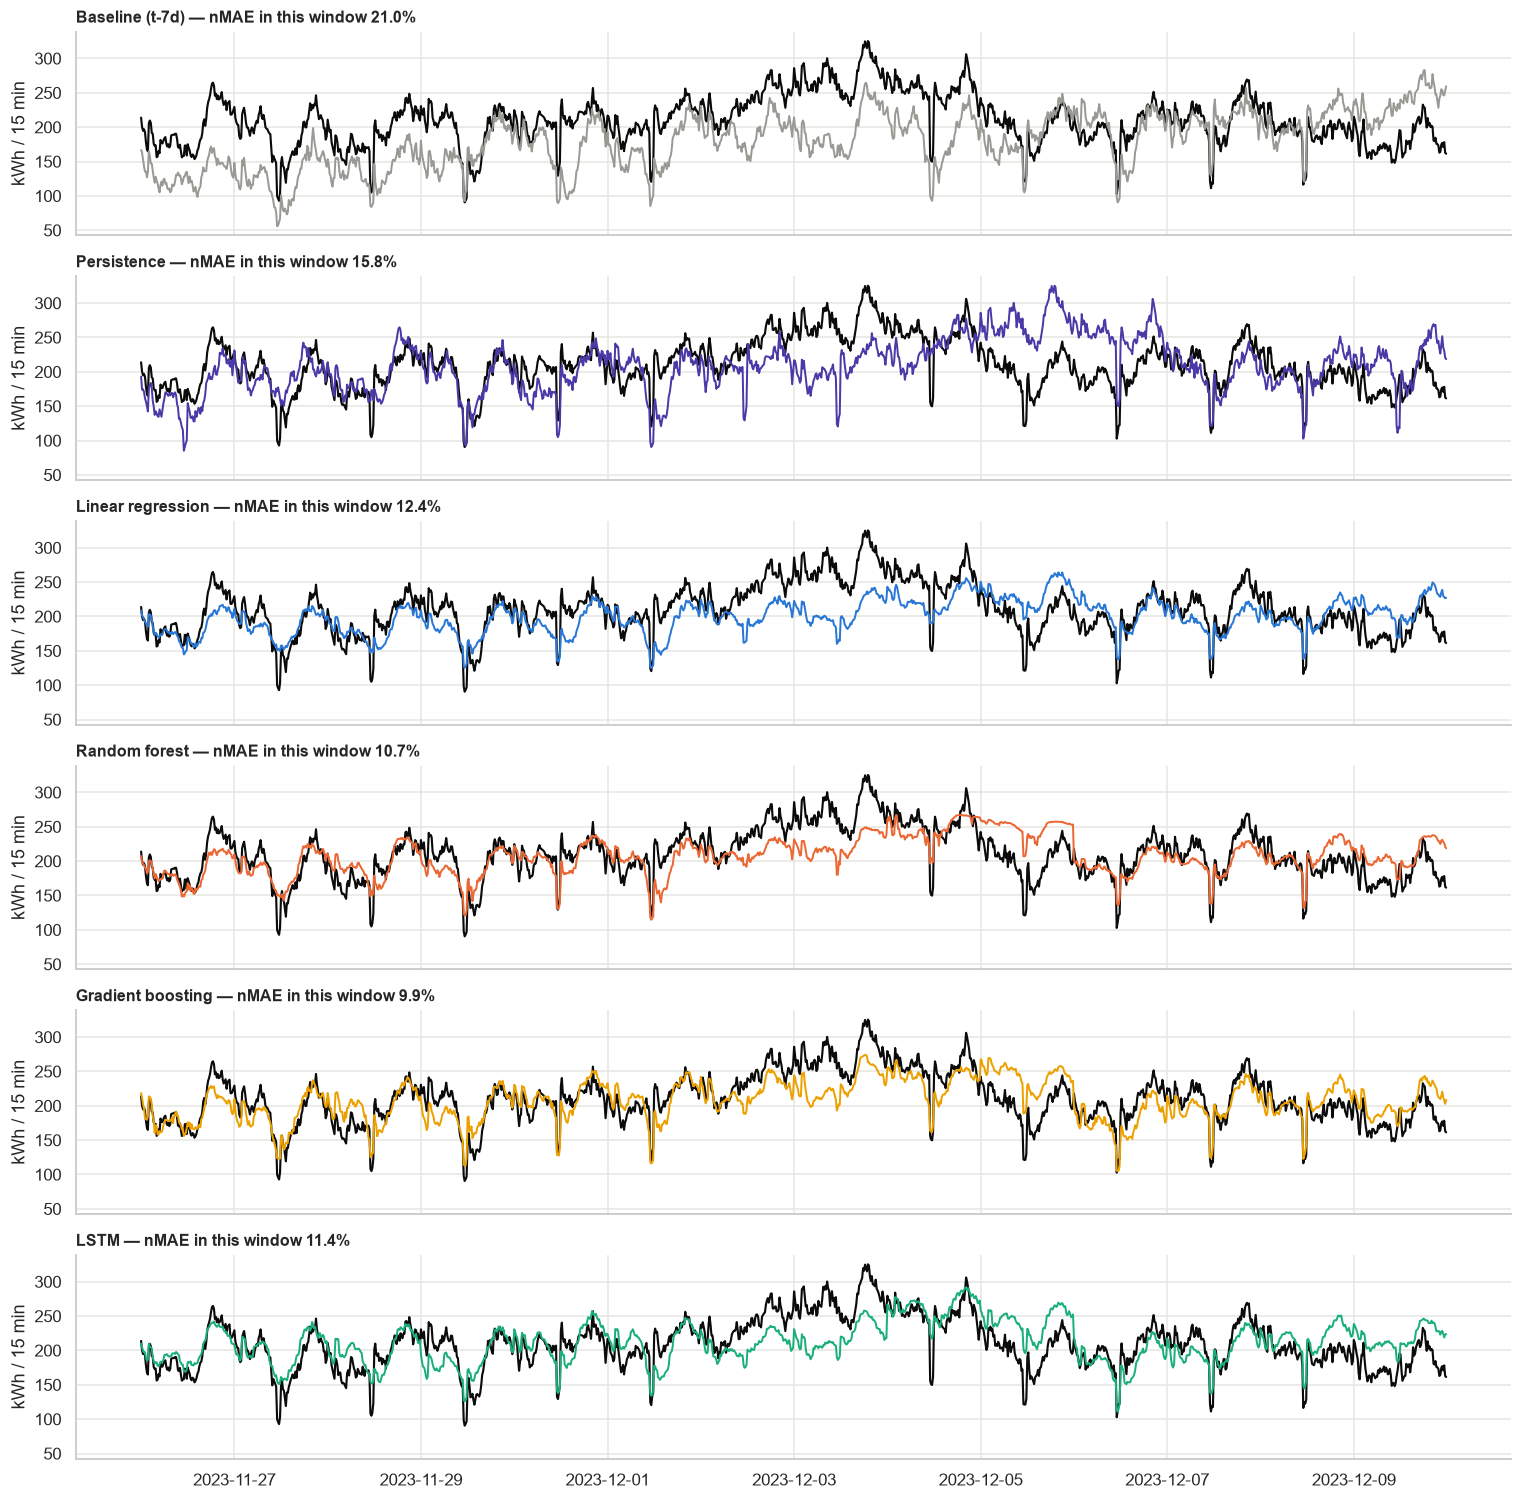

In [110]:
def quarter_hours(days):
    return days.repeat(STEPS) + pd.to_timedelta(np.tile(np.arange(STEPS) * 15, len(days)), unit="min")

# two weeks around the coldest test day; missing days appear as gaps
i0 =max(0, test_days.get_loc(picks["coldest day"]) - 7)
sel = slice(i0, i0 + 14)
ts = quarter_hours(test_days[sel])
full_ts = pd.date_range(ts[0], ts[-1], freq="15min")
on_grid = lambda v: pd.Series(np.asarray(v).ravel(), index=ts).reindex(full_ts)
fig, axes = plt.subplots(len(MODELS), 1, figsize=(14, 2.3 * len(MODELS)), sharex=True, sharey=True)
for ax, m in zip(axes, MODELS):
    ax.plot(full_ts, on_grid(actual_total[sel]), color=C_INK, lw=1.4, label="actual")
    ax.plot(full_ts, on_grid(pred_total[m][sel]), color=MODEL_COLORS[m], lw=1.3, label=m)
    ax.set_title(f"{m} — nMAE in this window "
                 f"{100 * np.abs(pred_total[m][sel] - actual_total[sel]).mean() / actual_total[sel].mean():.1f}%",
                 fontsize=10.5, loc="left")
    ax.set_ylabel("kWh / 15 min")
plt.tight_layout(); plt.show()

### 5.4 Where do the errors occur?

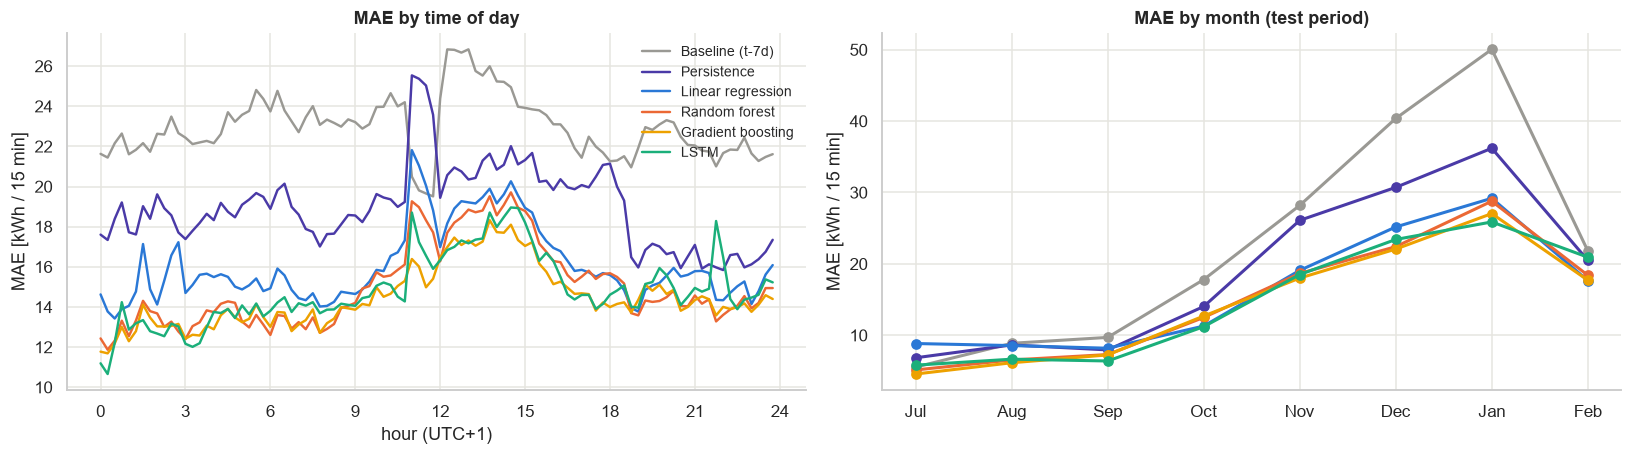

In [111]:
test_month = np.array([d.month for d in test_days])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
for m in MODELS:
    err = np.abs(pred_total[m] - actual_total)
    axes[0].plot(hours, err.mean(0), color=MODEL_COLORS[m], lw=1.6, label=m)
    by_month = pd.Series(err.mean(1)).groupby(test_month).mean()
    order = sorted(by_month.index, key=lambda x: (x < test_days[0].month, x))
    axes[1].plot(range(len(order)), by_month[order].values, marker="o", ms=6, color=MODEL_COLORS[m], label=m)
axes[0].set_title("MAE by time of day"); axes[0].set_xlabel("hour (UTC+1)"); axes[0].set_ylabel("MAE [kWh / 15 min]")
axes[0].set_xticks(range(0, 25, 3)); axes[0].legend(fontsize=9)
axes[1].set_xticks(range(len(order)), [pd.Timestamp(2000, k, 1).strftime("%b") for k in order])
axes[1].set_title("MAE by month (test period)"); axes[1].set_ylabel("MAE [kWh / 15 min]")
plt.tight_layout(); plt.show()

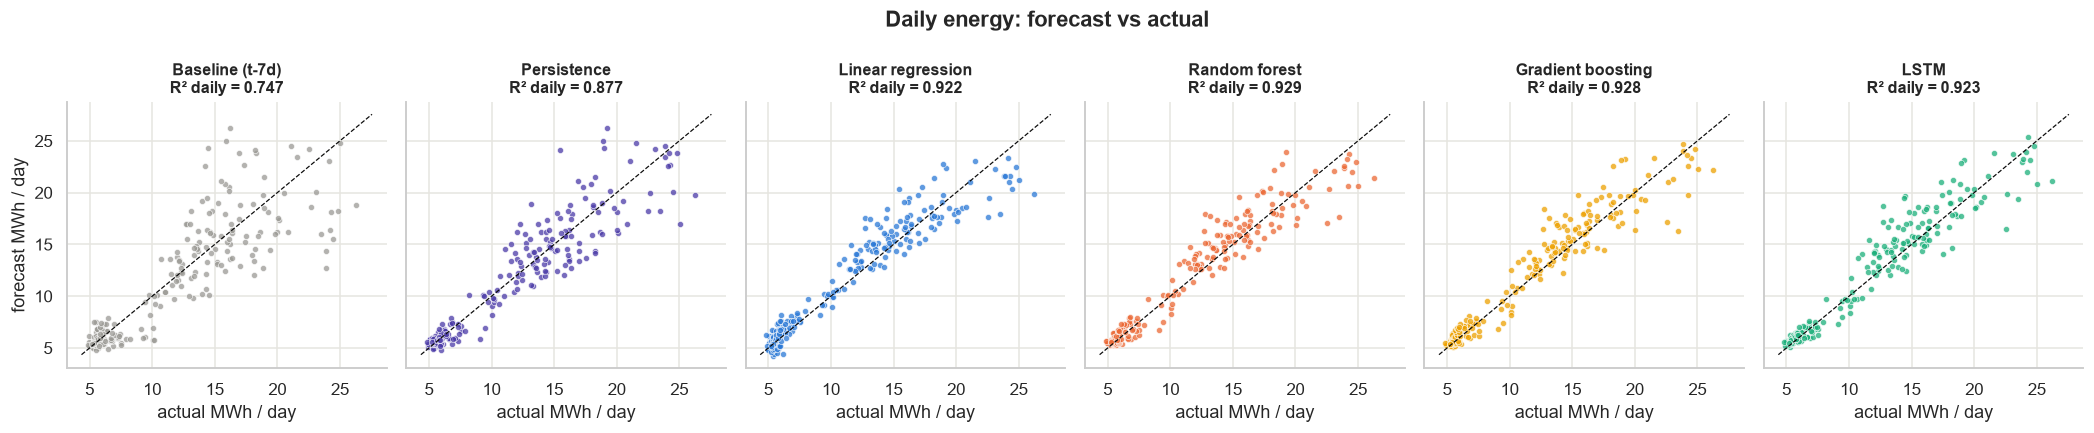

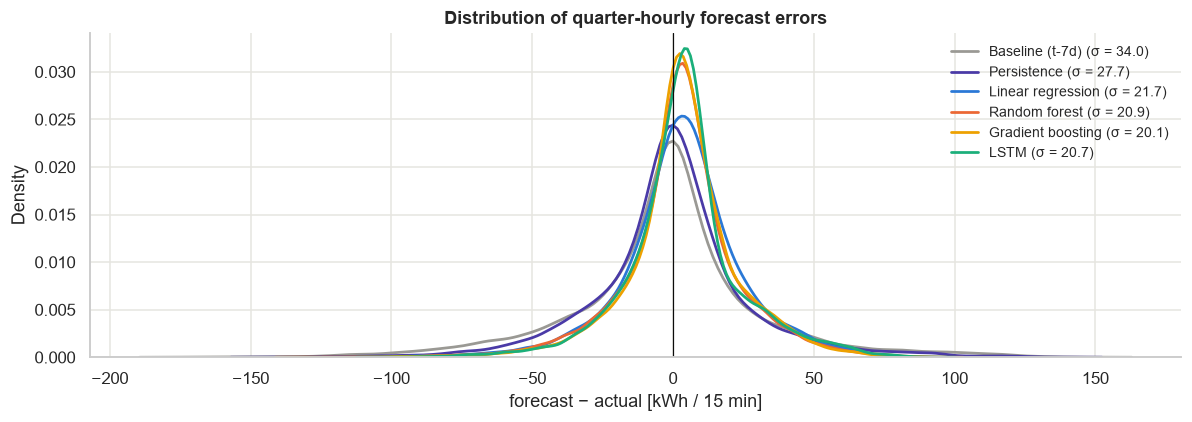

In [112]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(3.2 * len(MODELS), 4), sharex=True, sharey=True)
de_act = actual_total.sum(1) / 1000
lim = (de_act.min() * .9, de_act.max() * 1.05)
for ax, m in zip(axes, MODELS):
    de_p = pred_total[m].sum(1) / 1000
    ax.scatter(de_act, de_p, s=16, color=MODEL_COLORS[m], alpha=.75, edgecolor="white", linewidth=.5)
    ax.plot(lim, lim, color=C_INK, lw=.8, ls="--")
    ax.set_title(f"{m}\nR² daily = {r2_score(de_act, de_p):.3f}", fontsize=10.5); ax.set_xlabel("actual MWh / day")
axes[0].set_ylabel("forecast MWh / day")
plt.suptitle("Daily energy: forecast vs actual", fontweight="bold"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
for m in MODELS:
    e = (pred_total[m] - actual_total).ravel()
    sns.kdeplot(e, ax=ax, color=MODEL_COLORS[m], lw=1.8, label=f"{m} (σ = {e.std():.1f})")
ax.axvline(0, color=C_INK, lw=.8); ax.set_xlabel("forecast − actual [kWh / 15 min]")
ax.set_title("Distribution of quarter-hourly forecast errors"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

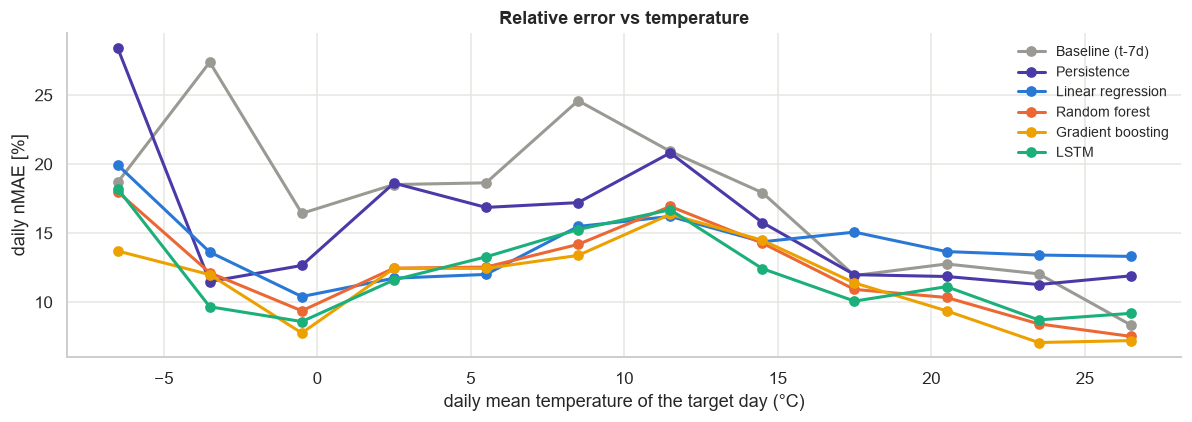

In [113]:
# error vs temperature of the target day
fig, ax = plt.subplots(figsize=(11, 4))
bins = pd.cut(test_temp.values, bins=np.arange(np.floor(test_temp.min()), test_temp.max() + 3, 3))
for m in MODELS:
    daily_nmae = 100 * np.abs(pred_total[m] - actual_total).mean(1) / actual_total.mean(1)
    s = pd.Series(daily_nmae).groupby(bins).mean()
    ax.plot([b.mid for b in s.index], s.values, marker="o", ms=6, color=MODEL_COLORS[m], label=m)
ax.set_xlabel("daily mean temperature of the target day (°C)"); ax.set_ylabel("daily nMAE [%]")
ax.set_title("Relative error vs temperature"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [114]:
# save test forecasts for further analysis (e.g. cost metrics / uncertainty in Levels 2-3)
OUT_FILE = RESULTS / "test_forecasts_15min_quick_test.csv"   # own name: do not overwrite the main notebook's results
out = pd.DataFrame({"timestamp": quarter_hours(test_days),
                    "actual_total_kWh": actual_total.ravel(),
                    "n_households_known_at_forecast": n_contract_test.ravel()})
for m in MODELS:
    out[f"forecast_{m}"] = pred_total[m].ravel()
out.to_csv(OUT_FILE, index=False)
print(f"Saved {len(out):,d} rows to {OUT_FILE}")
print("Run times [s]:", {k: round(v) for k, v in timings.items()})

Saved 22,944 rows to results\test_forecasts_15min_quick_test.csv
Run times [s]: {'linear HPO': 8, 'linear fit': 0, 'random forest HPO': 413, 'random forest fit': 9, 'gradient boosting HPO': 2709, 'gradient boosting fit': 27, 'LSTM HPO': 506, 'LSTM fit': 47}


## 6. Conclusions

In [115]:
best_model = res.loc[MODELS, "nMAE [%]"].idxmin()
summary = res.loc[MODELS,
                  ["nMAE [%]", "Daily energy error [%]", "Daily peak error [%]", "Skill vs best baseline [%]"]].round(2)
print(f"Best model on the test period: {best_model}")
summary

Best model on the test period: Gradient boosting


,nMAE [%],Daily energy error [%],Daily peak error [%],Skill vs best baseline [%]
Baseline (t-7d),19.4800,14.3600,12.2900,-21.1400
Persistence,16.0800,10.3300,9.7300,0.0000
Linear regression,13.6300,10.0100,9.4500,15.2600
Random forest,12.7200,9.0600,8.0800,20.9200
Gradient boosting,12.2600,8.8500,7.4000,23.7300
LSTM,12.5900,8.9600,7.3800,21.7200
